# 5. LMEs

In [1]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/samples_processing.R")
source("../util/outliers_processing.R")
source("../util/lme_helpers.R")

ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")
HEALTH_METRIC_WITH_EXPOSURE_DFS <- read_rds("../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")
HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS <- read_rds("../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")
SLEEP_STAGE_WITH_EXPOSURE_DFS <- read_rds("../R-table/SLEEP_STAGE_WITH_EXPOSURE_DFS.rds")
HEALTH_METRIC_COUNTS <- read_rds("../R-table/HEALTH_METRIC_COUNTS.rds")

SLEEP_STAGE_WITH_EXPOSURE_DFS <-
  SLEEP_STAGE_WITH_EXPOSURE_DFS[
    names(SLEEP_STAGE_WITH_EXPOSURE_DFS) %in% SLEEP_STAGES_FOR_ANALYSIS
  ]

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme


Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘HLMdiag’



## 5.1. Preparation before LME

### 5.1.1. Outlier removal
To improve statistical power, we removed outliers from each health endpoint with the IQR method and excluded participants who had fewer observations than the cohort's IQR lower bound, treating them as data sparsity outliers to minimize the influence of underrepresented individuals.

In [2]:
remove_lower_bound_participant_outliers <- function(df_list) {
  purrr::imap(df_list, function(df, metric_name) {
    
    # 1. Count rows per pseudonym per treatment
    row_counts <- df |>
      count(treatment, pseudonym, name = "n_rows")

    cat("\n========================================")
    cat("\nMETRIC:", metric_name)
    cat("\n========================================\n")

    # 2. Identify outlier pseudonyms by treatment group
    outlier_ids <- row_counts |>
      group_by(treatment) |>
      group_map(function(data, group) {
        iqr_stats <- quantile(data$n_rows, probs = c(0.25, 0.75), na.rm = TRUE)
        iqr <- iqr_stats[2] - iqr_stats[1]
        lower_bound <- iqr_stats[1] - 1.5 * iqr

        outliers <- data |>
          filter(n_rows < lower_bound)

        # Print per-treatment details
        cat("Treatment:", as.character(group$treatment), "\n")
        cat("Lower bound (1.5*IQR):", lower_bound, "\n")

        if (nrow(outliers) > 0) {
          cat("Removing outlier pseudonyms:", paste(outliers$pseudonym, collapse = ", "), "\n")
        } else {
          cat("No outliers detected.\n")
        }
        cat("----------------------------------------\n")

        outliers$pseudonym
      }) |>
      unlist() |> 
      unique()

    # 3. Filter the original dataframe
    df |> filter(!pseudonym %in% outlier_ids)
  })
}

# Apply to Health Metrics
HEALTH_METRIC_WITH_EXPOSURE_DFS <- remove_lower_bound_participant_outliers(HEALTH_METRIC_WITH_EXPOSURE_DFS)

# Apply to Sleep Stages
SLEEP_STAGE_WITH_EXPOSURE_DFS <- remove_lower_bound_participant_outliers(SLEEP_STAGE_WITH_EXPOSURE_DFS)


METRIC: heart-rate
Treatment: treatment1 
Lower bound (1.5*IQR): -442.5 
No outliers detected.
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): -65.625 
No outliers detected.
----------------------------------------

METRIC: resting-heart-rate
Treatment: treatment1 
Lower bound (1.5*IQR): 3.375 
Removing outlier pseudonyms: lettuce1, zebra6 
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): 4 
Removing outlier pseudonyms: lettuce1, mango6 
----------------------------------------

METRIC: hrv
Treatment: treatment1 
Lower bound (1.5*IQR): 24 
Removing outlier pseudonyms: dubai7, zebra6 
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): -4.75 
No outliers detected.
----------------------------------------

METRIC: respiratory-rate
Treatment: treatment1 
Lower bound (1.5*IQR): 151.5 
Removing outlier pseudonyms: dubai7, lettuce1, zebra6 
----------------------------------------

In [3]:
HEALTH_METRIC_AFTER_PARTICIPANT_OUTLIER_COUNTS <- bind_rows(
    lapply(names(HEALTH_METRIC_WITH_EXPOSURE_DFS), function(metric) {
        HEALTH_METRIC_WITH_EXPOSURE_DFS[[metric]] |>
            count(treatment, name = "n_after_participant_lower_bound_outlier_removed") |>
            mutate(metric = metric) |>
            select(metric, treatment, n_after_participant_lower_bound_outlier_removed)
    })
)
HEALTH_METRIC_AFTER_PARTICIPANT_OUTLIER_COUNTS

metric,treatment,n_after_participant_lower_bound_outlier_removed
<chr>,<chr>,<int>
heart-rate,treatment1,114068
heart-rate,treatment2,109754
resting-heart-rate,treatment1,451
resting-heart-rate,treatment2,435
hrv,treatment1,2842
hrv,treatment2,2720
respiratory-rate,treatment1,18568
respiratory-rate,treatment2,18158
oxygen-saturation,treatment1,6662


In [4]:
HEALTH_METRIC_COUNTS_FINAL <- HEALTH_METRIC_COUNTS |>
    left_join(
        HEALTH_METRIC_AFTER_PARTICIPANT_OUTLIER_COUNTS,
        by = c("metric", "treatment")
    ) |>
    mutate(
        n_after_participant_lower_bound_outlier_removed = replace_na(
            n_after_participant_lower_bound_outlier_removed,
            0L
        ),

        n_removed_by_participant_lower_bound_outlier =
            n_after_time_matching_to_personal_exposure -
            n_after_participant_lower_bound_outlier_removed,

        pct_removed_by_participant_lower_bound_outlier_of_original = if_else(
            n_original > 0,
            100 * n_removed_by_participant_lower_bound_outlier / n_original,
            NA_real_
        ),

        pct_kept_after_participant_lower_bound_outlier_of_original = if_else(
            n_original > 0,
            100 * n_after_participant_lower_bound_outlier_removed / n_original,
            NA_real_
        )
    )
HEALTH_METRIC_COUNTS_FINAL

metric,treatment,n_original,n_after_travel_removed,n_removed_by_travel,pct_removed_by_travel_of_original,n_after_outlier_removed,n_removed_by_outlier_iqr,pct_removed_by_outlier_iqr_of_original,n_total_removed,pct_total_removed_of_original,n_after_time_matching_to_personal_exposure,n_removed_by_time_matching_to_personal_exposure,pct_removed_by_time_matching_to_personal_exposure_of_original,pct_kept_after_time_matching_to_personal_exposure_of_original,n_after_participant_lower_bound_outlier_removed,n_removed_by_participant_lower_bound_outlier,pct_removed_by_participant_lower_bound_outlier_of_original,pct_kept_after_participant_lower_bound_outlier_of_original
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
heart-rate,treatment1,133389,126386,7003,5.250058,121679,4707,3.528777,11710,8.778835,114068,7611,5.7058678,85.51530,114068,0,0.0000000,85.51530
heart-rate,treatment2,132440,122336,10104,7.629115,117641,4695,3.545002,14799,11.174117,109754,7887,5.9551495,82.87073,109754,0,0.0000000,82.87073
resting-heart-rate,treatment1,513,487,26,5.068226,462,25,4.873294,51,9.941520,457,5,0.9746589,89.08382,451,6,1.1695906,87.91423
resting-heart-rate,treatment2,510,474,36,7.058824,453,21,4.117647,57,11.176471,448,5,0.9803922,87.84314,435,13,2.5490196,85.29412
hrv,treatment1,3393,3215,178,5.246095,3067,148,4.361922,326,9.608017,2867,200,5.8944887,84.49749,2842,25,0.7368111,83.76068
hrv,treatment2,3329,3115,214,6.428357,2983,132,3.965155,346,10.393512,2793,190,5.7074196,83.89907,2720,73,2.1928507,81.70622
respiratory-rate,treatment1,22498,21372,1126,5.004889,20225,1147,5.098231,2273,10.103120,19139,1086,4.8270957,85.06978,18568,571,2.5380034,82.53178
respiratory-rate,treatment2,21996,20545,1451,6.596654,19470,1075,4.887252,2526,11.483906,18750,720,3.2733224,85.24277,18158,592,2.6913984,82.55137
oxygen-saturation,treatment1,7854,7420,434,5.525847,7107,313,3.985230,747,9.511077,6685,422,5.3730583,85.11586,6662,23,0.2928444,84.82302


In [5]:
format_row <- function(n, pct) {
  paste0(format(n, big.mark = ","), " (", sprintf("%.1f", pct), "\\%)")
}

observation_table_latex <- HEALTH_METRIC_COUNTS_FINAL |>
  mutate(
    metric_name = HEALTH_METRIC_NAMES[metric],
    treatment = TREATMENT_LABELS[treatment]
  ) |>
  arrange(metric_name, treatment) |>
  transmute(
    `Metric` = metric_name,
    `Filter` = treatment,
    `Original` = format_row(n_original, 100),
    `After Travel Exclusion` = format_row(
      n_after_travel_removed,
      100 * n_after_travel_removed / n_original
    ),
    `After IQR Outlier Exclusion` = format_row(
      n_after_outlier_removed,
      100 * n_after_outlier_removed / n_original
    ),
    `After Exposure Time Matching` = format_row(
      n_after_time_matching_to_personal_exposure,
      pct_kept_after_time_matching_to_personal_exposure_of_original
    ),
    `After Data Sparsity Outlier Removal` = format_row(
      n_after_participant_lower_bound_outlier_removed,
      pct_kept_after_participant_lower_bound_outlier_of_original
    )
  )

group_end_rows <- seq(2, nrow(observation_table_latex), by = 2)

observation_table_latex |>
  kable(
    format = "latex",
    booktabs = TRUE,
    escape = FALSE,
    align = "llccccc"
  ) |>
  collapse_rows(
    columns = 1,
    valign = "middle",
    latex_hline = "none"
  ) |>
  row_spec(
    group_end_rows,
    extra_latex_after = "\\hline"
  ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))


\begin{table}[!h]
\centering
\begin{tabular}{llccccc}
\toprule
Metric & Filter & Original & After Travel Exclusion & After IQR Outlier Exclusion & After Exposure Time Matching & After Data Sparsity Outlier Removal\\
\midrule
 & Placebo Filter & 133,389 (100.0\%) & 126,386 (94.7\%) & 121,679 (91.2\%) & 114,068 (85.5\%) & 114,068 (85.5\%)\\

\multirow{-2}{*}{\raggedright\arraybackslash HR} & Real Filter & 132,440 (100.0\%) & 122,336 (92.4\%) & 117,641 (88.8\%) & 109,754 (82.9\%) & 109,754 (82.9\%)\\
\hline

 & Placebo Filter & 3,393 (100.0\%) & 3,215 (94.8\%) & 3,067 (90.4\%) & 2,867 (84.5\%) & 2,842 (83.8\%)\\

\multirow{-2}{*}{\raggedright\arraybackslash HRV} & Real Filter & 3,329 (100.0\%) & 3,115 (93.6\%) & 2,983 (89.6\%) & 2,793 (83.9\%) & 2,720 (81.7\%)\\
\hline

 & Placebo Filter & 513 (100.0\%) & 487 (94.9\%) & 462 (90.1\%) & 457 (89.1\%) & 451 (87.9\%)\\

\multirow{-2}{*}{\raggedright\arraybackslash RHR} & Real Filter & 510 (100.0\%) & 474 (92.9\%) & 453 (88.8\%) & 448 (87.8\%) 

### 5.1.2. Some descriptive stats

In [6]:
hrv_data <- HEALTH_METRIC_WITH_EXPOSURE_DFS[[HRV]]
summary_stats <- hrv_data %>%
    summarise(
        mean = round(mean(value, na.rm = TRUE), 1),
        sd = round(sd(value, na.rm = TRUE), 1),
        median = round(median(value, na.rm = TRUE), 1),
        q25 = round(quantile(value, 0.25, na.rm = TRUE), 1),
        q75 = round(quantile(value, 0.75, na.rm = TRUE), 1),
        q05 = round(quantile(value, 0.05, na.rm = TRUE), 1),
        q95 = round(quantile(value, 0.95, na.rm = TRUE), 1),
    )
summary_stats


mean,sd,median,q25,q75,q05,q95
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
52.6,25.1,47.1,34.7,64.8,21.9,100.5


In [7]:
sleep_sd <- SLEEP_STAGE_WITH_EXPOSURE_DFS[[ASLEEP_ALL]] |>
  group_by(pseudonym) |>
  summarise(
    sd_total_sleep_duration = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

sleep_sd |>
  summarise(
    min = min(sd_total_sleep_duration, na.rm = TRUE),
    q25  = quantile(sd_total_sleep_duration, 0.25, na.rm = TRUE),
    median = quantile(sd_total_sleep_duration, 0.50, na.rm = TRUE),
    q75  = quantile(sd_total_sleep_duration, 0.75, na.rm = TRUE),
    max = max(sd_total_sleep_duration, na.rm = TRUE)
  )

min,q25,median,q75,max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5128478,1.054693,1.387639,1.77061,3.332083


### 5.1.3. Join with participant metadata for LME
To control for fixed covariates like BMI, sex...

In [8]:
metadata_to_join <- ALL_PARTICIPANTS_METADATA |> select(pseudonym, bmi, biological_sex, age_group)

HEALTH_METRIC_WITH_EXPOSURE_DFS <- lapply(HEALTH_METRIC_WITH_EXPOSURE_DFS, function(df) {
    left_join(df, metadata_to_join, by = "pseudonym")
})


In [9]:
HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS <- lapply(HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS, function(df) {
    left_join(df, metadata_to_join, by = "pseudonym")
})

In [10]:
SLEEP_STAGE_WITH_EXPOSURE_DFS <- lapply(SLEEP_STAGE_WITH_EXPOSURE_DFS, function(df) {
    left_join(df, metadata_to_join, by = "pseudonym")
})

## 5.2. LME for health metric
(excluding sleep)

### 5.2.1. Treatment <-> Health metric

In [11]:
health_metric_treatment_lme_models <- fit_lme_models(
    main_fixed_effect = "treatment",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)

health_metric_treatment_lme_summaries <- imap(
  health_metric_treatment_lme_models,
  ~ extract_model_info(
      model = .x$model,
      main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
      df_used = .x$df_used,
      metric_name = .y,
      main_fixed_effect = "treatment"
    )
)

health_metric_treatment_lme_summaries <- adjust_pvalues_bh(lme_summaries = health_metric_treatment_lme_summaries, main_fixed_effect = "treatmenttreatment2")

[1] "Fitting model for metric: heart-rate"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: hrv"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: respiratory-rate"


...

[1] "Adjusted overall mean for hrv = 54.73"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 35077' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for respiratory-rate = 14.76"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10641' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for oxygen-saturation = 97.19"


In [12]:
view_lme_summary_details(lme_summaries = health_metric_treatment_lme_summaries)

log(value) ~ treatment + treatment_order + first_or_second_half + 
    bmi + biological_sex + ns(temperature, df = 3) + ns(humidity, 
    df = 3) + ns(co2, df = 3) + dow + heart_rate_motion_context + 
    ns(hour, df = 3) + (1 | pseudonym + date)
<environment: 0x12a7c6bf8>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
heart-rate,-152122.2,0.1409675,141510


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.477793603,4.335769481,4.619817726,0.0724626186,61.79453195,40.42758,1.199260e-41,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,-0.006337921,-0.007901581,-0.004774262,0.0007978001,-7.94424753,141158.59493,1.967994e-15,-0.6317879,-0.7870445,-0.4762883,NA,NA,NA,7.871977e-15
fixed,treatment_order,-0.004830170,-0.013015132,0.003354791,0.0041760775,-1.15662856,36.94363,2.548487e-01,-0.4818524,-1.2930801,0.3360425,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,0.007433434,-0.001508230,0.016375098,0.0045621573,1.62936809,73.55172,1.075109e-01,0.7461130,-0.1507094,1.6509904,NA,NA,NA,NA
fixed,bmi,0.022846104,-0.014445459,0.060137667,0.0190266573,1.20074188,37.01783,2.374786e-01,2.3109075,-1.4341624,6.1982737,NA,NA,NA,NA
fixed,biological_sexMale,-0.002485447,-0.075743115,0.070772220,0.0373770476,-0.06649662,36.94484,9.473410e-01,-0.2482361,-7.2945677,7.3336713,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.085898766,0.075813896,0.095983635,0.0051454362,16.69416605,131019.43728,1.677550e-62,8.9696008,7.8761794,10.0741051,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.124710417,0.092655188,0.156765647,0.0163550093,7.62521225,136956.25937,2.451925e-14,13.2820360,9.7083383,16.9721454,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",0.009355120,-0.005151784,0.023862023,0.0074016175,1.26392908,137441.31514,2.062576e-01,0.9399016,-0.5138536,2.4148999,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.0004234753,0.02057852,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.0117779695,0.10852635,NA,NA
ran_pars,Residual,sd__Observation,0.0198718470,0.14096754,NA,NA


,treatment,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,66.65063,1.186066,Inf,64.36605,69.01629
2,treatment2,66.22954,1.178564,Inf,63.95941,68.58024


...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
oxygen-saturation,-57370.43,0.01596477,10641


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.573436e+00,4.5427468841,4.6041260307,0.0156582333,292.07870219,3596.49883,0.000000e+00,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,9.872450e-04,0.0003434481,0.0016310420,0.0003284739,3.00555134,9646.53520,2.657816e-03,0.098773253,0.03435071,0.16323728,NA,NA,NA,0.005315631
fixed,treatment_order,-5.842835e-04,-0.0010610123,-0.0001075548,0.0002432334,-2.40215156,33.34250,2.202368e-02,-0.058411289,-0.10604496,-0.01075490,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,-1.321413e-03,-0.0022197502,-0.0004230749,0.0004583440,-2.88301513,81.08108,5.041346e-03,-0.132053987,-0.22172884,-0.04229854,NA,NA,NA,NA
fixed,bmi,1.017288e-03,-0.0011384037,0.0031729797,0.0010998629,0.92492257,35.58584,3.612362e-01,0.101780563,-0.11377559,0.31780189,NA,NA,NA,NA
fixed,biological_sexMale,2.638473e-03,-0.0016315354,0.0069084805,0.0021786155,1.21107763,33.84301,2.342551e-01,0.264195636,-0.16302052,0.69323991,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",2.200115e-03,-0.0017625745,0.0061628048,0.0020218176,1.08818678,1692.85899,2.766676e-01,0.220253719,-0.17610221,0.61818340,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",7.598568e-03,-0.0048076420,0.0200047774,0.0063298151,1.20044070,1401.19240,2.301711e-01,0.762751007,-0.47961038,2.02062139,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-2.190877e-03,-0.0070078039,0.0026260493,0.0024576608,-0.89144820,3549.62080,3.727492e-01,-0.218847905,-0.69833065,0.26295004,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),1.605163e-06,0.001266950,NA,NA
ran_pars,pseudonym,sd__(Intercept),3.498761e-05,0.005915033,NA,NA
ran_pars,Residual,sd__Observation,2.548738e-04,0.015964767,NA,NA


,treatment,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,97.14358,0.1083538,Inf,96.93144,97.35618
2,treatment2,97.23953,0.1086349,Inf,97.02684,97.45268


[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


[1] "Saved image"


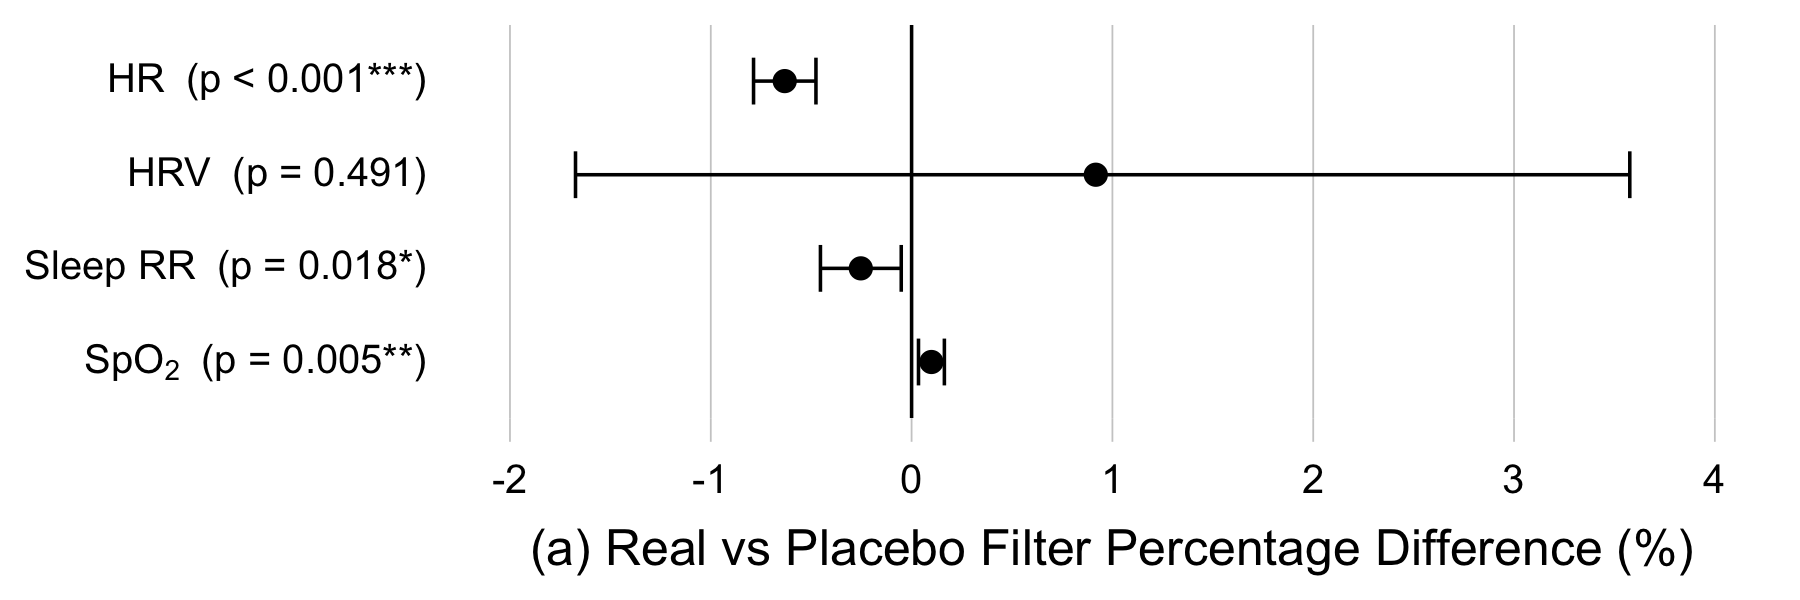

In [13]:
p1 <- plot_fixed_effect_percentage(
    main_fixed_effect =  "treatmenttreatment2",
    summaries = health_metric_treatment_lme_summaries, 
    health_metric_names = HEALTH_METRIC_PLOT_LABELS, 
    is_black_bg = FALSE,
    title = "(a) Real vs Placebo Filter Percentage Difference (%)",
    file_name = "percentage_change_health_metrics_treatment.pdf"
)
p1

In [14]:
health_metric_treatment_report_df <- make_reporting_treatment_df(
  lme_summaries = health_metric_treatment_lme_summaries,
  trt1 = "treatment1",
  trt2 = "treatment2",
  trt2_term = "treatmenttreatment2",
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)

health_metric_treatment_report_df

latex_tbl <- kable(
  health_metric_treatment_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccccc",
  col.names = c(
  "Metric",  "N", TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],  "Percentage Changes (Real vs. Placebo)", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_treatment",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,emmean1_pm_se,emmean2_pm_se,pct_change_iqr,p_value
<chr>,<int>,<chr>,<chr>,<chr>,<chr>
HR (beats/min),141510,$66.65~\pm~1.19$,$66.23~\pm~1.18$,"$-0.63\%$ $[-0.79, -0.48]$",\textbf{<0.001$^{***}$}
HRV (ms),3571,$54.48~\pm~2.82$,$54.98~\pm~2.85$,"$+0.92\%$ $[-1.67, +3.58]$",0.491
Sleep RR (breaths/min),35077,$14.78~\pm~0.32$,$14.75~\pm~0.32$,"$-0.25\%$ $[-0.45, -0.05]$",\textbf{0.018$^*$}
SpO$_2$ (\%),10641,$97.14~\pm~0.11$,$97.24~\pm~0.11$,"$+0.10\%$ $[+0.03, +0.16]$",\textbf{0.005$^{**}$}


\begin{table}[!h]
\centering
\begin{tabular}{lccccc}
\toprule
Metric & N & Placebo Filter & Real Filter & Percentage Changes (Real vs. Placebo) & P-Value\tnote{a}\\
\midrule
HR (beats/min) & 141,510 & $66.65~\pm~1.19$ & $66.23~\pm~1.18$ & $-0.63\%$ $[-0.79, -0.48]$ & \textbf{<0.001$^{***}$}\\
HRV (ms) & 3,571 & $54.48~\pm~2.82$ & $54.98~\pm~2.85$ & $+0.92\%$ $[-1.67, +3.58]$ & 0.491\\
Sleep RR (breaths/min) & 35,077 & $14.78~\pm~0.32$ & $14.75~\pm~0.32$ & $-0.25\%$ $[-0.45, -0.05]$ & \textbf{0.018$^*$}\\
SpO$_2$ (\%) & 10,641 & $97.14~\pm~0.11$ & $97.24~\pm~0.11$ & $+0.10\%$ $[+0.03, +0.16]$ & \textbf{0.005$^{**}$}\\
\bottomrule
\end{tabular}
\end{table}

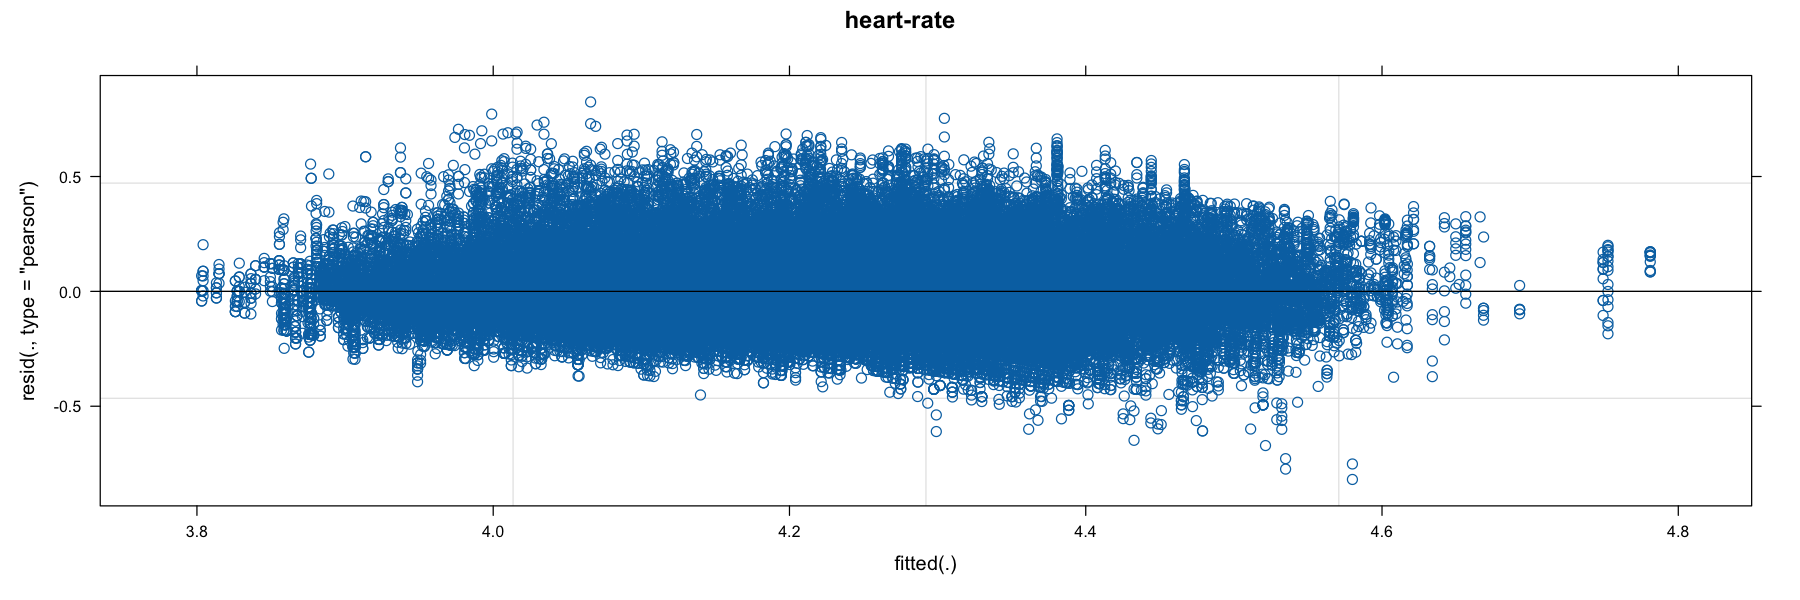

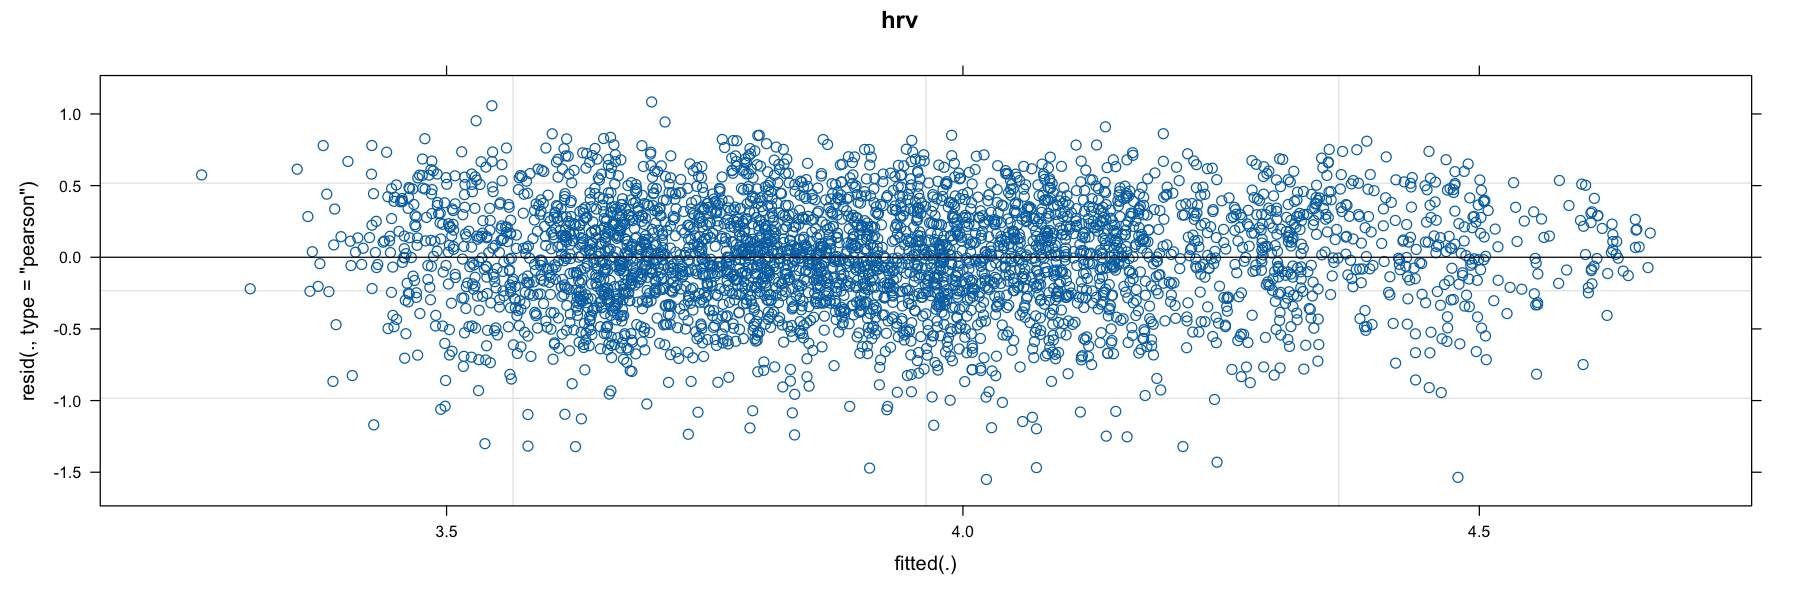

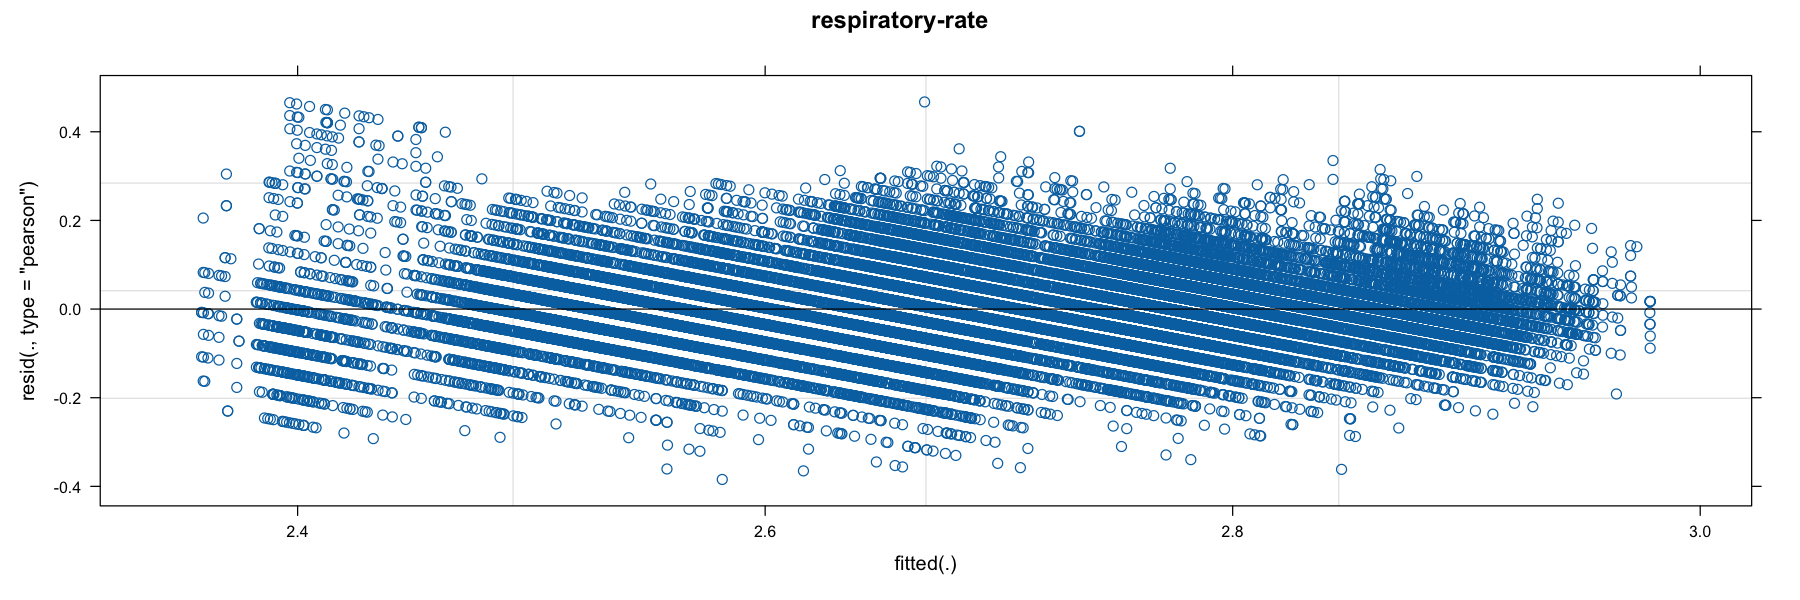

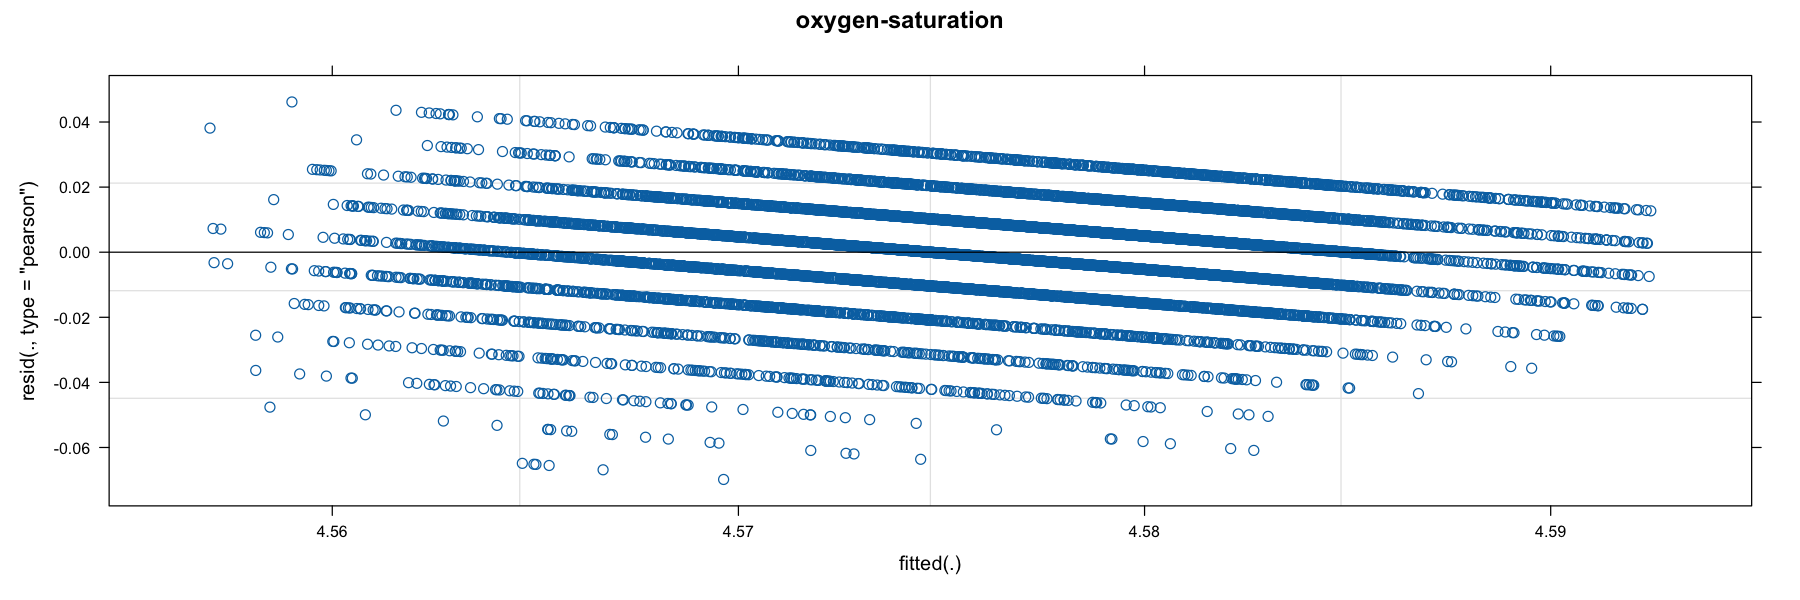

In [15]:
plot_lme_residuals_vs_fitted(health_metric_treatment_lme_summaries)

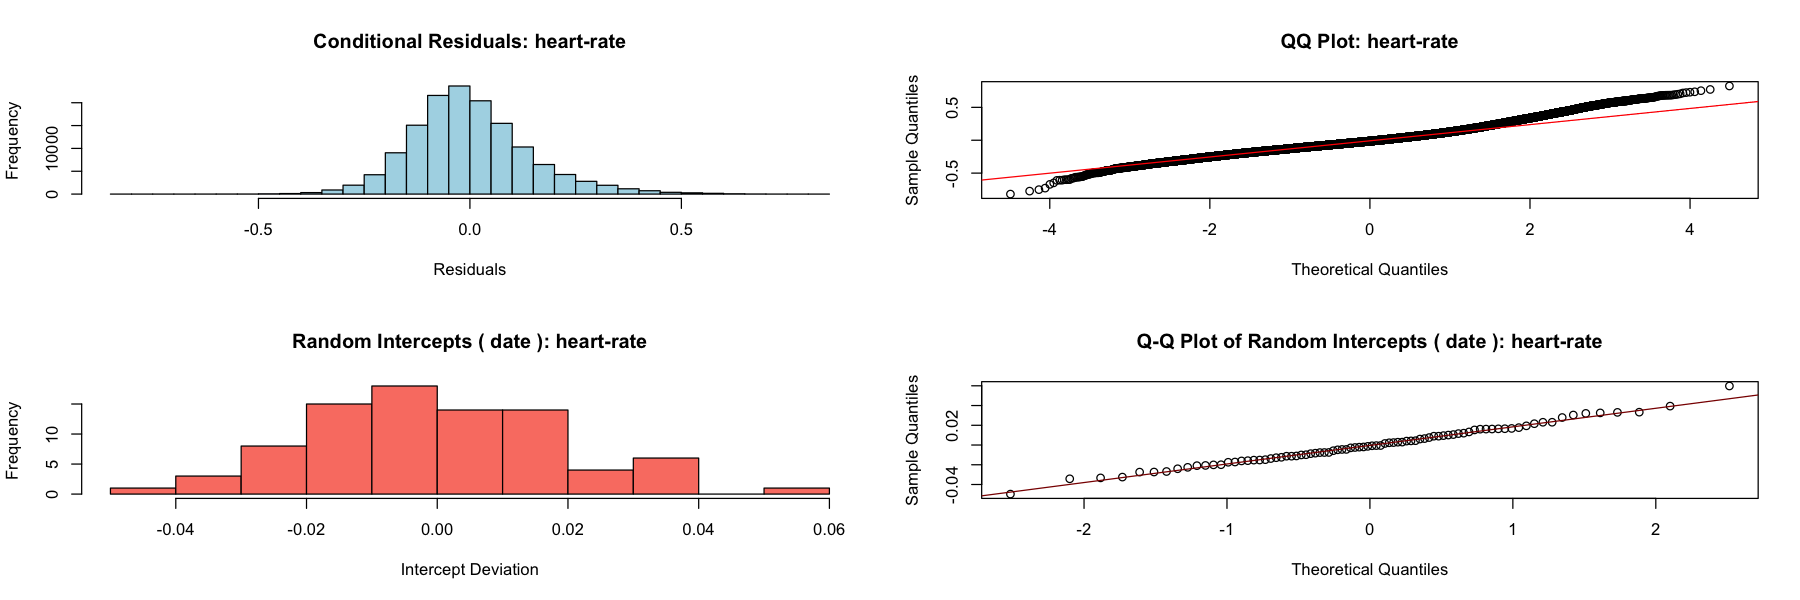

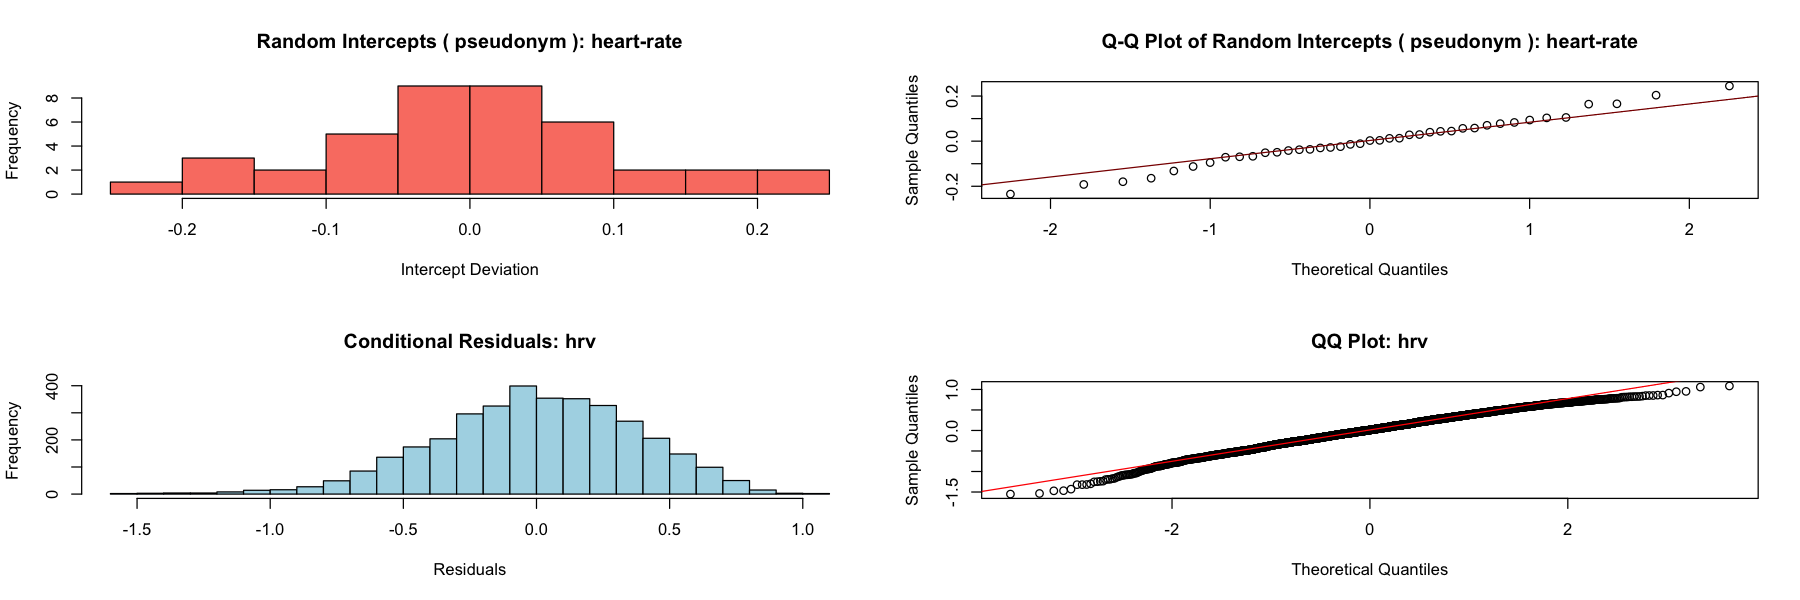

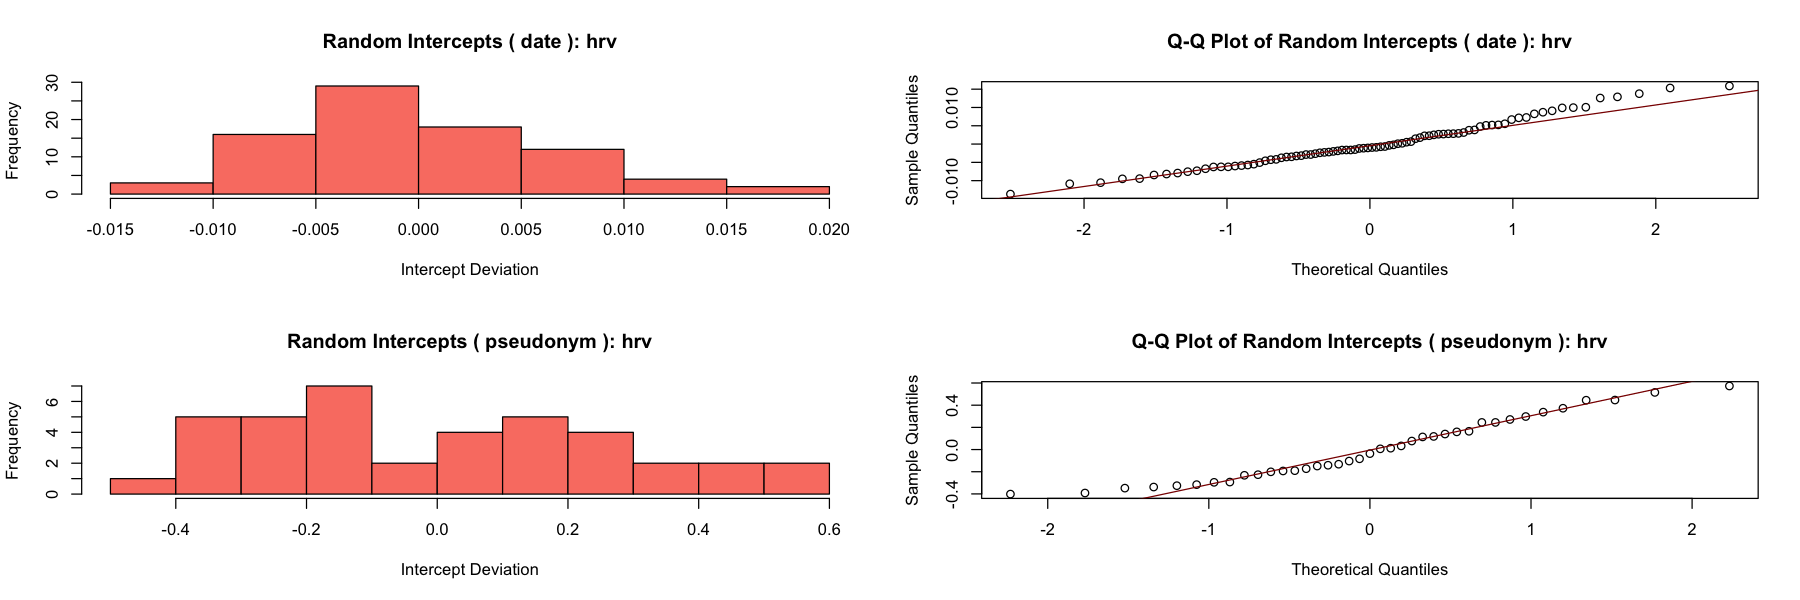

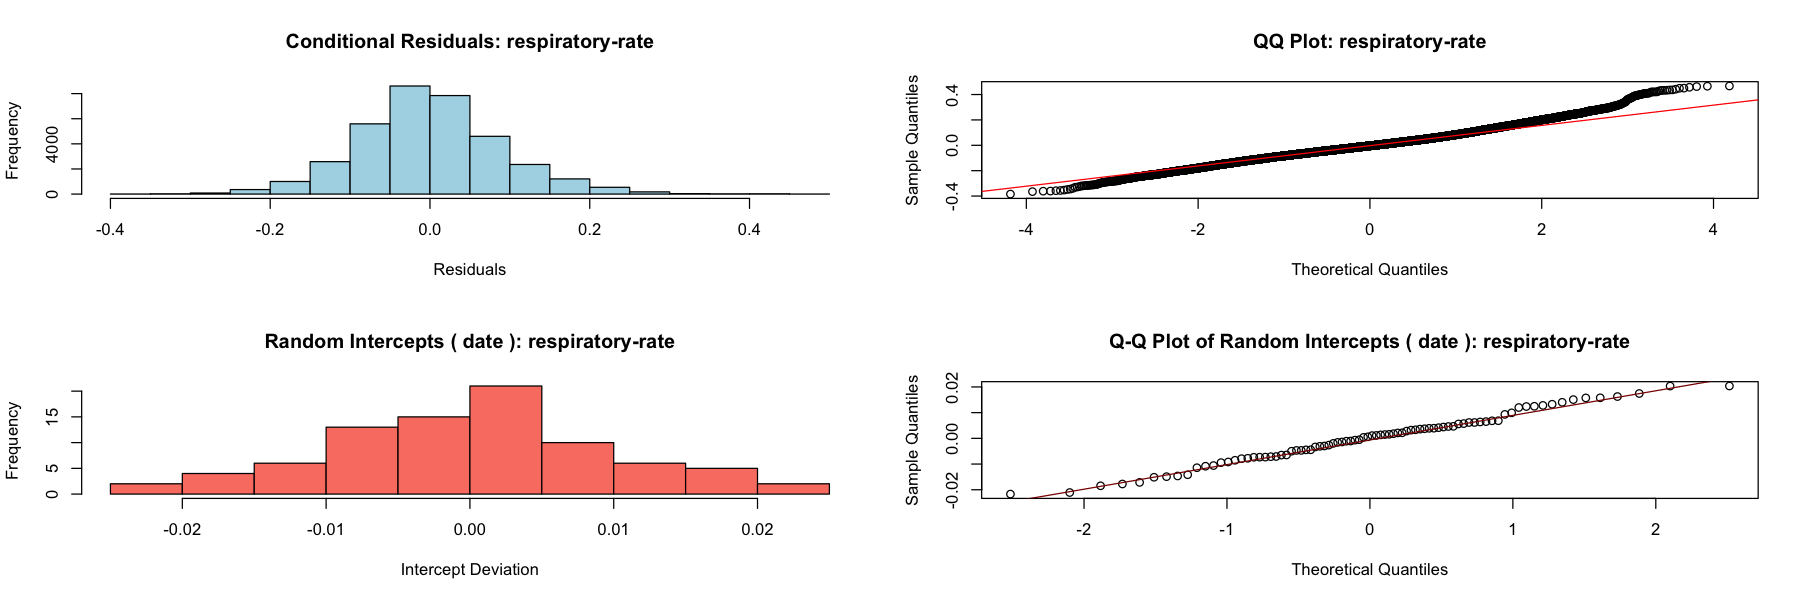

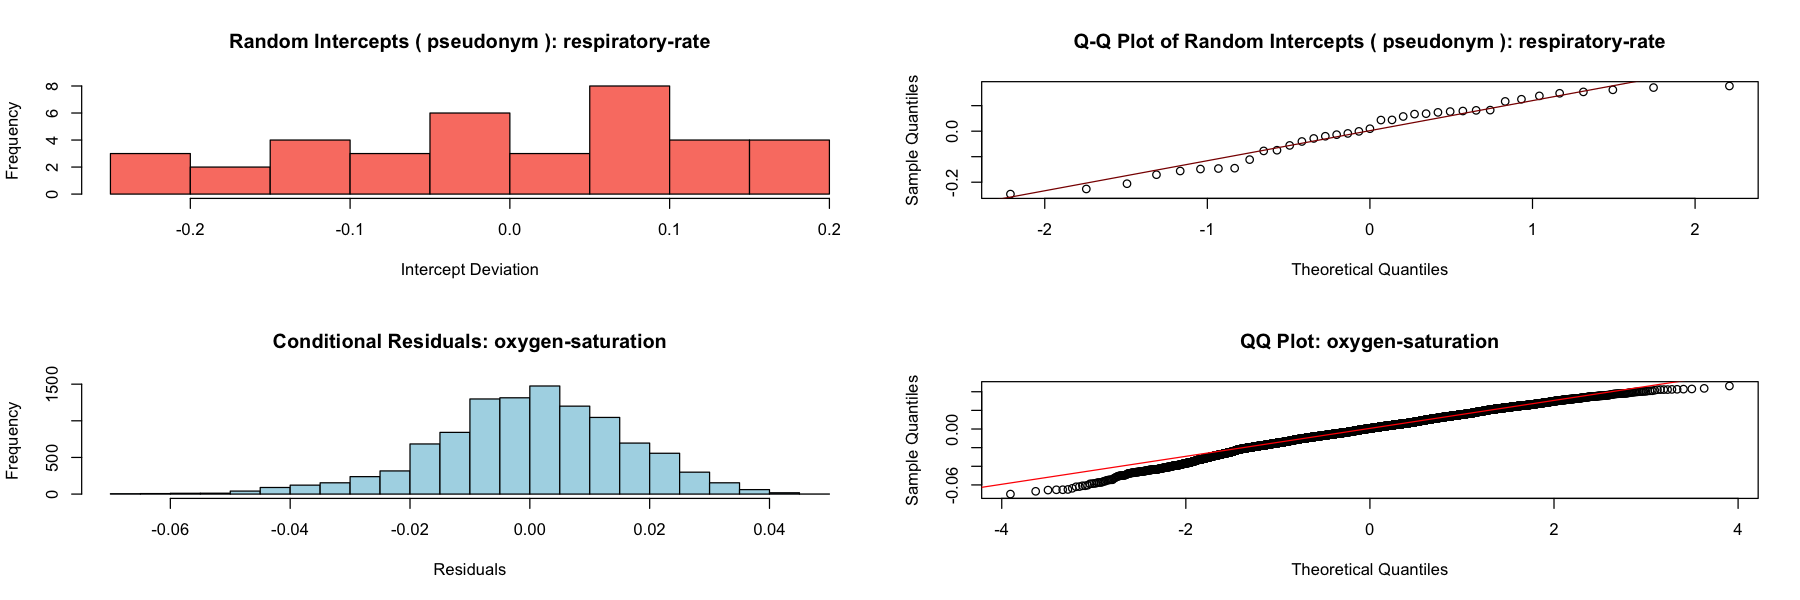

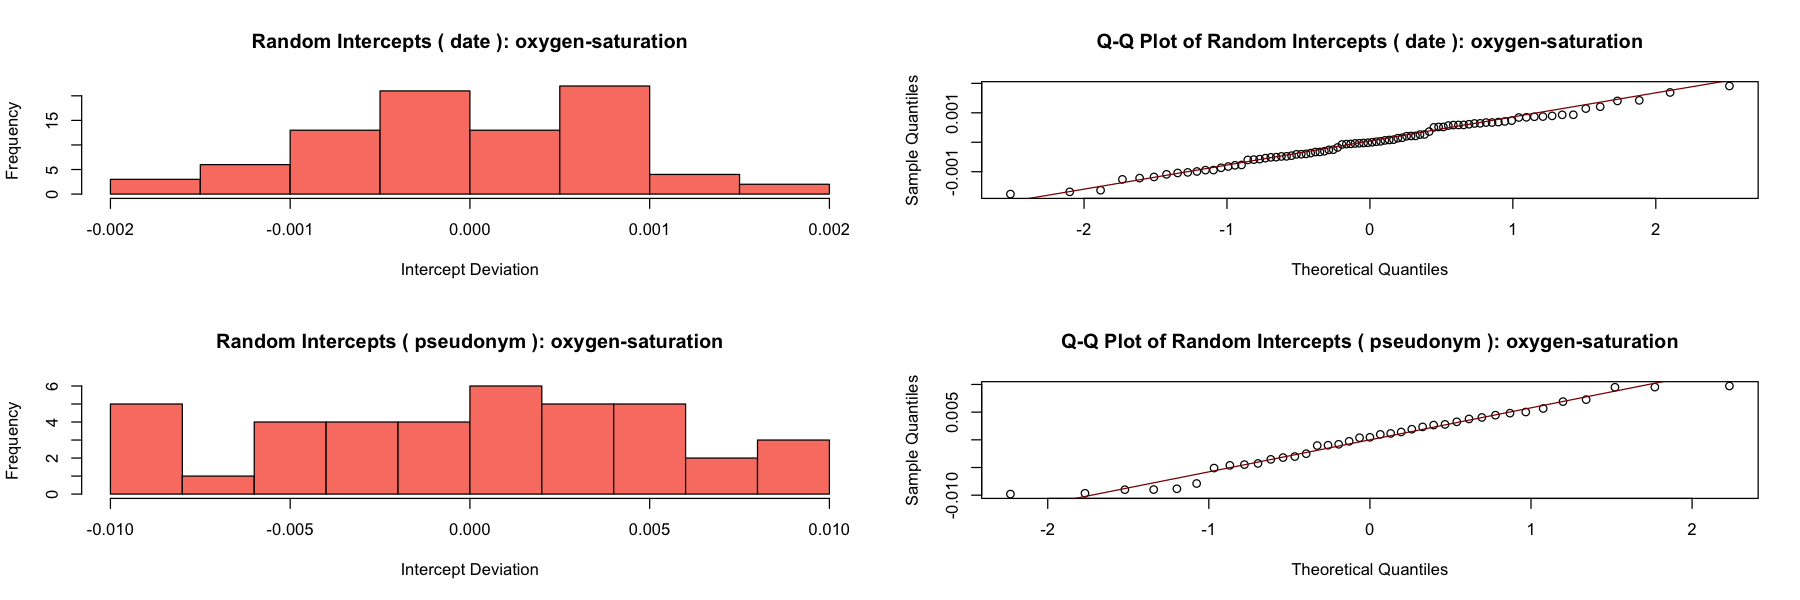

In [16]:
plot_lme_diagnostics(health_metric_treatment_lme_summaries)

### 5.2.2. PM2.5 exposure <-> Health metric

In [17]:
health_metric_pm25_lme_models <- fit_lme_models(
    main_fixed_effect = "pm25",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)
health_metric_pm25_lme_summaries <- imap(health_metric_pm25_lme_models, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
health_metric_pm25_lme_summaries <- adjust_pvalues_bh(lme_summaries = health_metric_pm25_lme_summaries, main_fixed_effect = "pm25")

[1] "Fitting model for metric: heart-rate"
[1] "Fitting model for metric: hrv"
[1] "Fitting model for metric: respiratory-rate"
[1] "Fitting model for metric: oxygen-saturation"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 141510' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 141510' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for heart-rate = 66.42"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3571' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3571)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3571' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3571)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for hrv = 54.76"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 35077' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for respiratory-rate = 14.76"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10641' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for oxygen-saturation = 97.19"


In [18]:
view_lme_summary_details(lme_summaries = health_metric_pm25_lme_summaries)

log(value) ~ pm25 + treatment_order + first_or_second_half + 
    bmi + biological_sex + ns(temperature, df = 3) + ns(humidity, 
    df = 3) + ns(co2, df = 3) + dow + heart_rate_motion_context + 
    ns(hour, df = 3) + (1 | pseudonym + date)
<environment: 0x1648b8710>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
heart-rate,-152234.5,0.1409123,141510


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.487451306,4.345654629,4.629247982,0.0723465725,62.02714452,40.43278,1.022228e-41,NA,NA,NA,NA,NA,NA,NA
fixed,pm25,0.006416571,0.005470098,0.007363044,0.0004829032,13.28748869,117605.48717,2.925521e-40,0.6437201,0.5485086,0.7390218,0.6437201,0.5485086,0.7390218,1.170208e-39
fixed,treatment_order,-0.005020679,-0.013192772,0.003151415,0.0041695121,-1.20414053,36.95357,2.361916e-01,-0.5008096,-1.3106129,0.3156386,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,0.004686298,-0.004118483,0.013491078,0.0044923175,1.04318041,73.87863,3.002663e-01,0.4697296,-0.4110014,1.3582493,NA,NA,NA,NA
fixed,bmi,0.023109259,-0.014123395,0.060341913,0.0189966011,1.21649441,37.02578,2.314949e-01,2.3378347,-1.4024128,6.2199664,NA,NA,NA,NA
fixed,biological_sexMale,-0.002505312,-0.075647720,0.070637095,0.0373182407,-0.06713372,36.95272,9.468372e-01,-0.2502177,-7.2857237,7.3191689,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.081065919,0.071008147,0.091123691,0.0051316108,15.79736325,130440.33438,3.658247e-56,8.4442380,7.3589972,9.5404489,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.119384522,0.087435445,0.151333599,0.0163008491,7.32382229,136821.89520,2.423229e-13,12.6803116,9.1371808,16.3384698,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",0.006220332,-0.008254185,0.020694849,0.0073850936,0.84228208,137329.79684,3.996315e-01,0.6239718,-0.8220213,2.0910473,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.0004094426,0.02023469,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.0117410254,0.10835601,NA,NA
ran_pars,Residual,sd__Observation,0.0198562835,0.14091233,NA,NA


NULL

...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
oxygen-saturation,-57365.17,0.01596796,10641


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.572639e+00,4.5419597667,4.603319e+00,0.0156531427,292.12276734,3633.51340,0.000000e+00,NA,NA,NA,NA,NA,NA,NA
fixed,pm25,-4.131417e-04,-0.0007777879,-4.849560e-05,0.0001860474,-2.22062663,2033.71836,2.648607e-02,-0.041305641,-0.07774855,-0.004849442,-0.04130564,-0.07774855,-0.004849442,0.03531477
fixed,treatment_order,-5.670482e-04,-0.0010410043,-9.309222e-05,0.0002418187,-2.34493092,33.34831,2.512874e-02,-0.056688750,-0.10404626,-0.009308789,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,-1.117094e-03,-0.0020230080,-2.111806e-04,0.0004622094,-2.41685787,81.52481,1.788747e-02,-0.111647060,-0.20209631,-0.021115833,NA,NA,NA,NA
fixed,bmi,1.042743e-03,-0.0011000186,3.185504e-03,0.0010932657,0.95378712,35.56790,3.466289e-01,0.104328658,-0.10994138,0.319058322,NA,NA,NA,NA
fixed,biological_sexMale,2.618866e-03,-0.0016251600,6.862892e-03,0.0021653591,1.20943720,33.81108,2.348840e-01,0.262229811,-0.16238402,0.688649543,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",2.979137e-03,-0.0009554274,6.913701e-03,0.0020074676,1.48402736,1691.79568,1.379879e-01,0.298357889,-0.09549711,0.693765586,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",8.996905e-03,-0.0033568784,2.135069e-02,0.0063030665,1.42738538,1401.12638,1.536917e-01,0.903749882,-0.33512504,2.158024520,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-1.667925e-03,-0.0064781330,3.142283e-03,0.0024542328,-0.67961156,3578.06583,4.967944e-01,-0.166653480,-0.64571951,0.314722510,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),1.621941e-06,0.001273555,NA,NA
ran_pars,pseudonym,sd__(Intercept),3.454143e-05,0.005877196,NA,NA
ran_pars,Residual,sd__Observation,2.549757e-04,0.015967957,NA,NA


NULL

[1] "main_fixed_effect_iqr: 5.4"
[1] "main_fixed_effect_iqr: 5.54545454545455"
[1] "main_fixed_effect_iqr: 5.3125"
[1] "main_fixed_effect_iqr: 5.36363636363636"


[1] "Saved image"


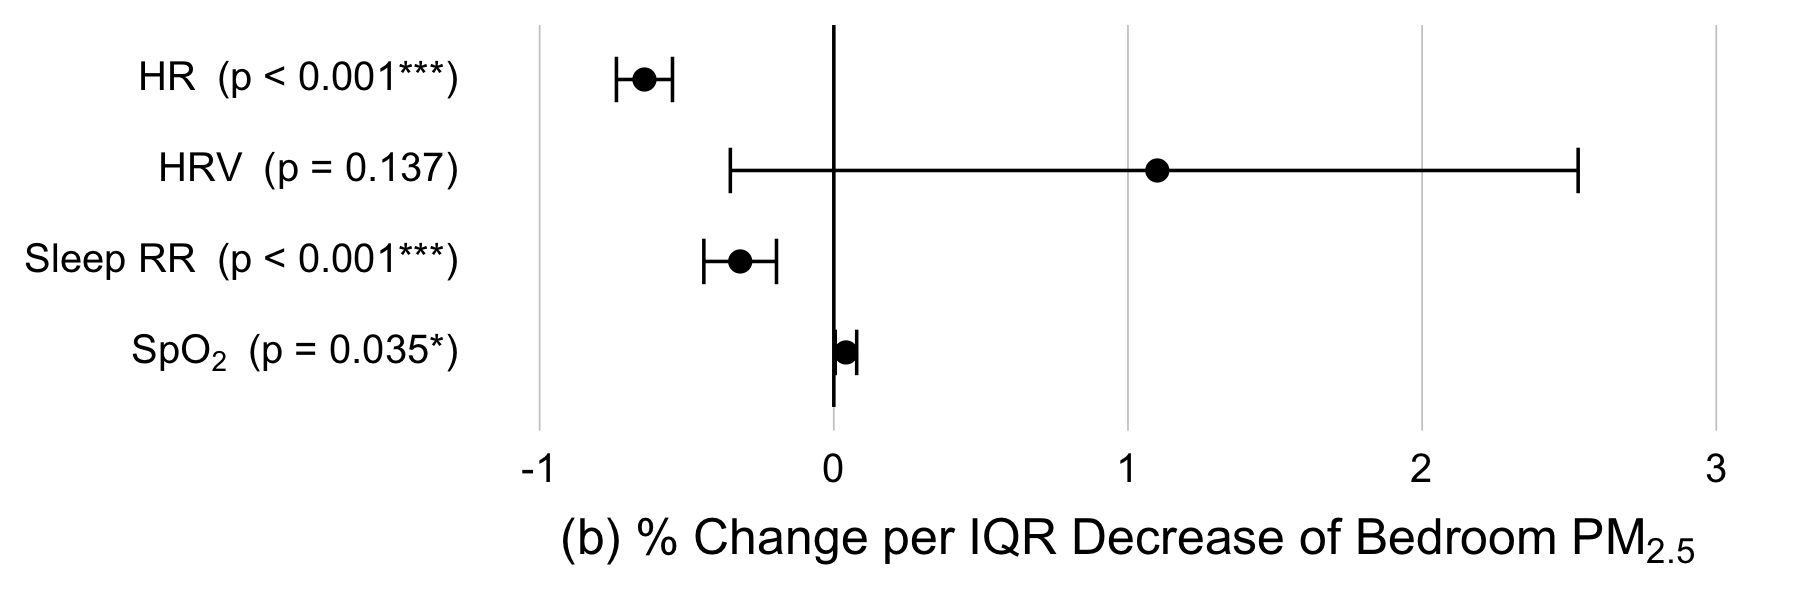

In [19]:
p2 <- plot_fixed_effect_percentage(
    main_fixed_effect = "pm25",
    summaries = health_metric_pm25_lme_summaries, 
    health_metric_names = HEALTH_METRIC_PLOT_LABELS, 
    is_black_bg = FALSE,
    title = expression("(b) % Change per IQR Decrease of Bedroom " * PM[2.5]),
    flip_direction = TRUE,
    file_name = "percentage_change_health_metrics_pm25.pdf"
)
p2

In [20]:
health_metric_pm25_report_df <- make_reporting_pm25_df(
  lme_summaries = health_metric_pm25_lme_summaries,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = HEALTH_METRIC_NAMES
)

health_metric_pm25_report_df

latex_tbl <- kable(
  health_metric_pm25_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccccc",
  col.names = c(
  "Metric", "N", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_pm25",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<int>,<dbl>,<chr>,<chr>
HR,141510,5.4,"$-0.64\%$ $[-0.74, -0.55]$",\textbf{<0.001$^{***}$}
HRV,3571,5.5,"$+1.10\%$ $[-0.35, +2.53]$",0.137
Sleep RR,35077,5.3,"$-0.32\%$ $[-0.44, -0.19]$",\textbf{<0.001$^{***}$}
SpO2,10641,5.4,"$+0.04\%$ $[+0.00, +0.08]$",\textbf{0.035$^*$}


\begin{table}[!h]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & N & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
HR & 141,510 & 5.4 & $-0.64\%$ $[-0.74, -0.55]$ & \textbf{<0.001$^{***}$}\\
HRV & 3,571 & 5.5 & $+1.10\%$ $[-0.35, +2.53]$ & 0.137\\
Sleep RR & 35,077 & 5.3 & $-0.32\%$ $[-0.44, -0.19]$ & \textbf{<0.001$^{***}$}\\
SpO2 & 10,641 & 5.4 & $+0.04\%$ $[+0.00, +0.08]$ & \textbf{0.035$^*$}\\
\bottomrule
\end{tabular}
\end{table}

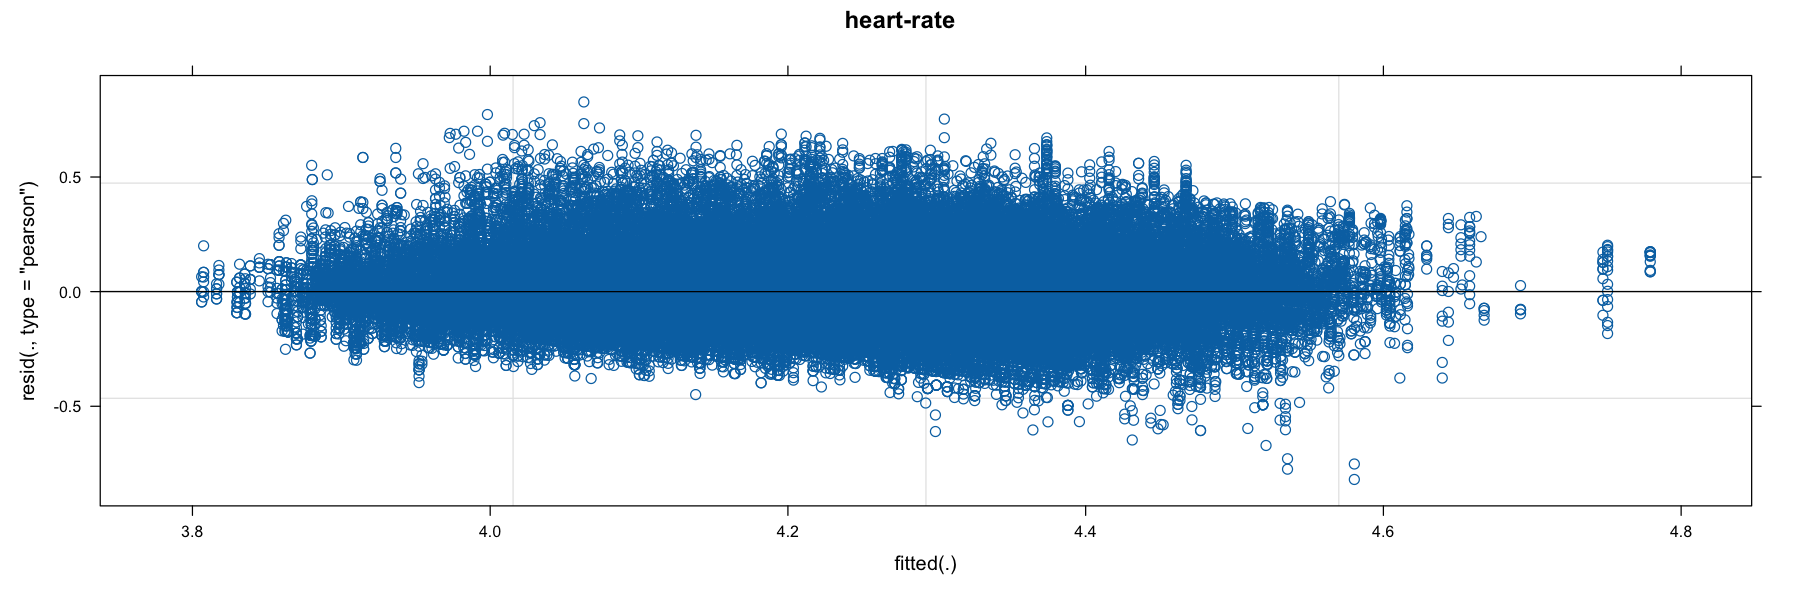

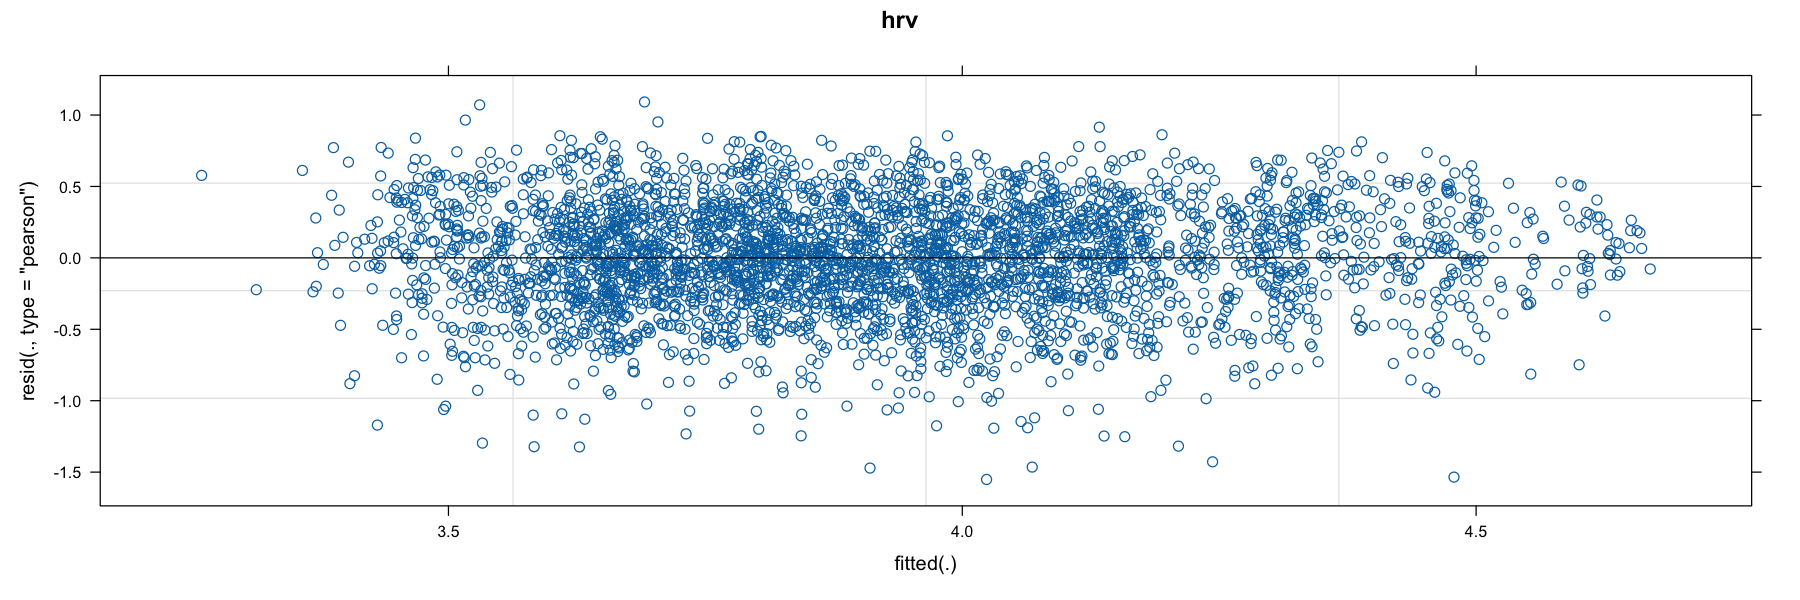

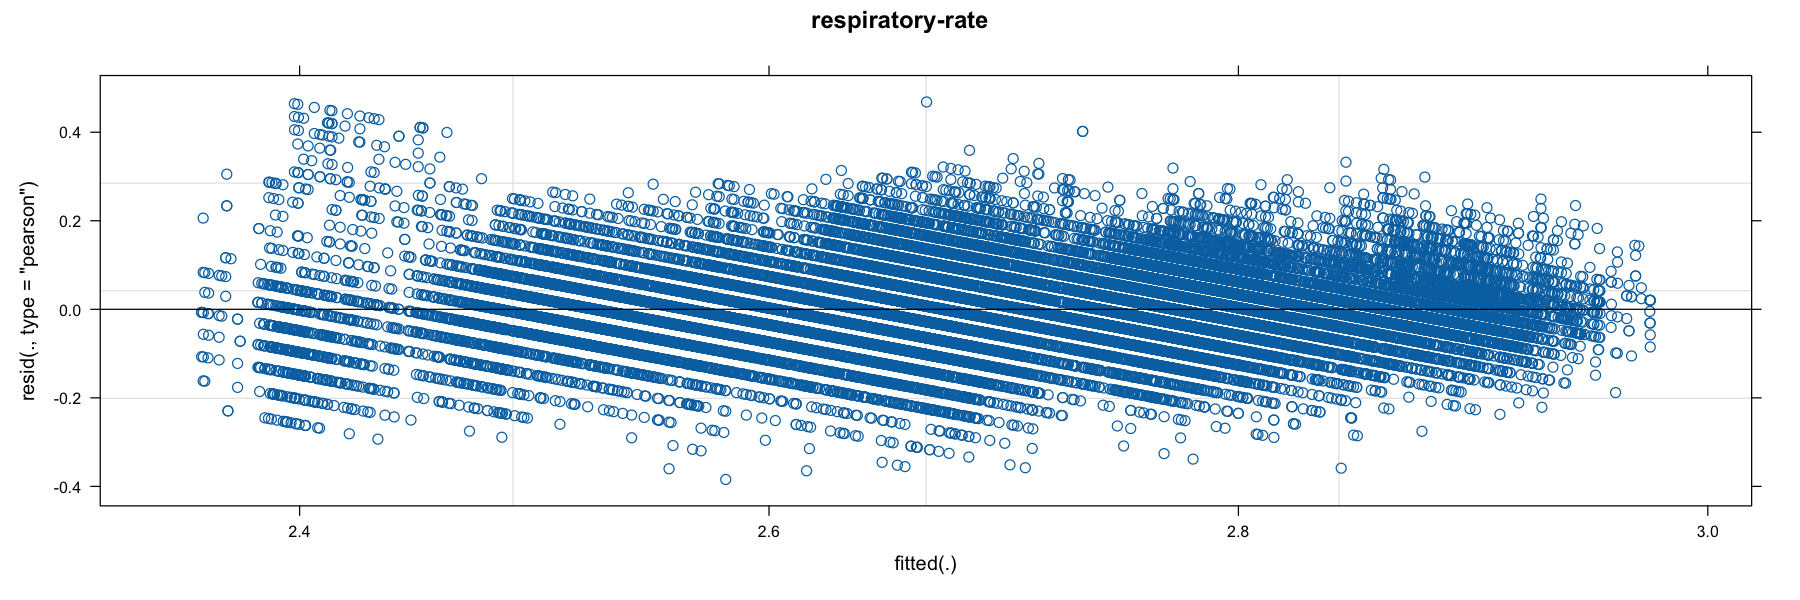

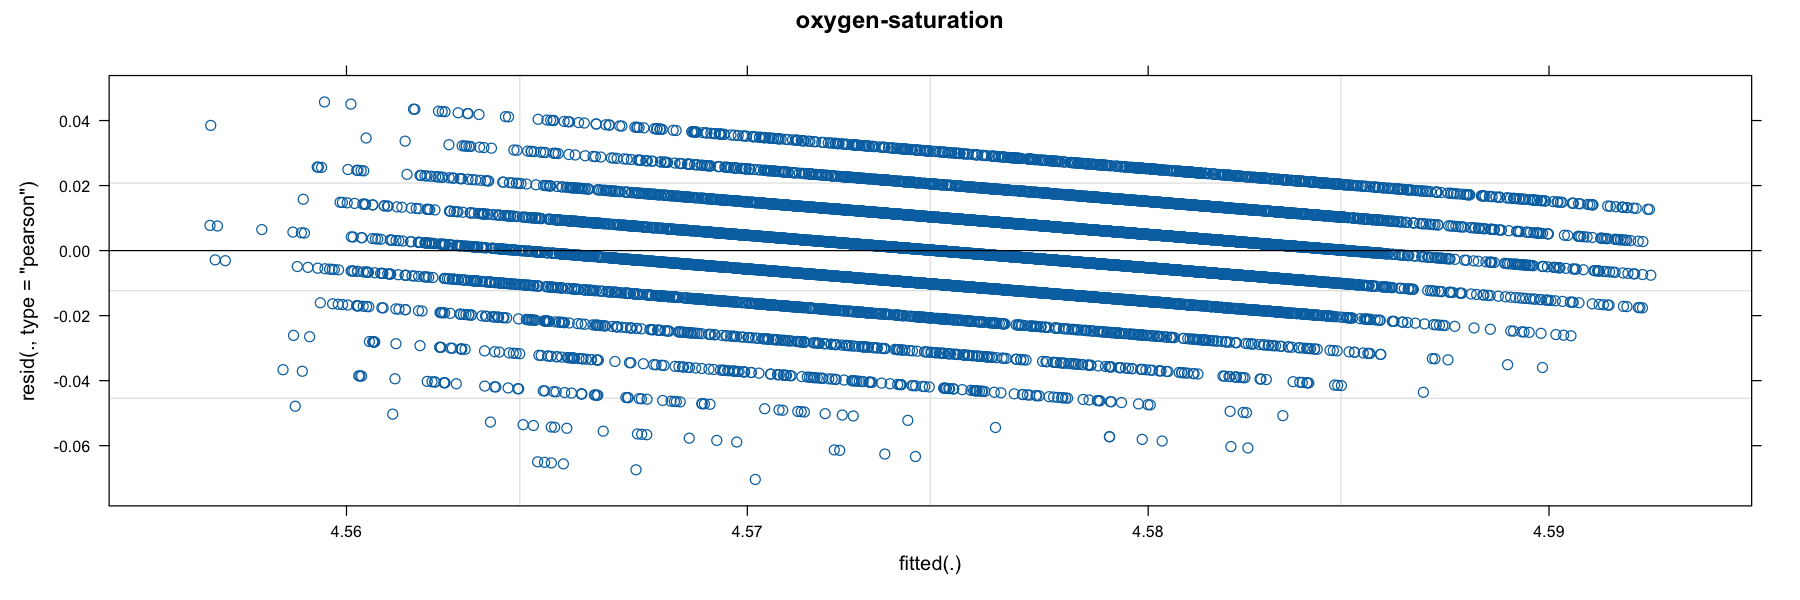

In [21]:
plot_lme_residuals_vs_fitted(health_metric_pm25_lme_summaries)

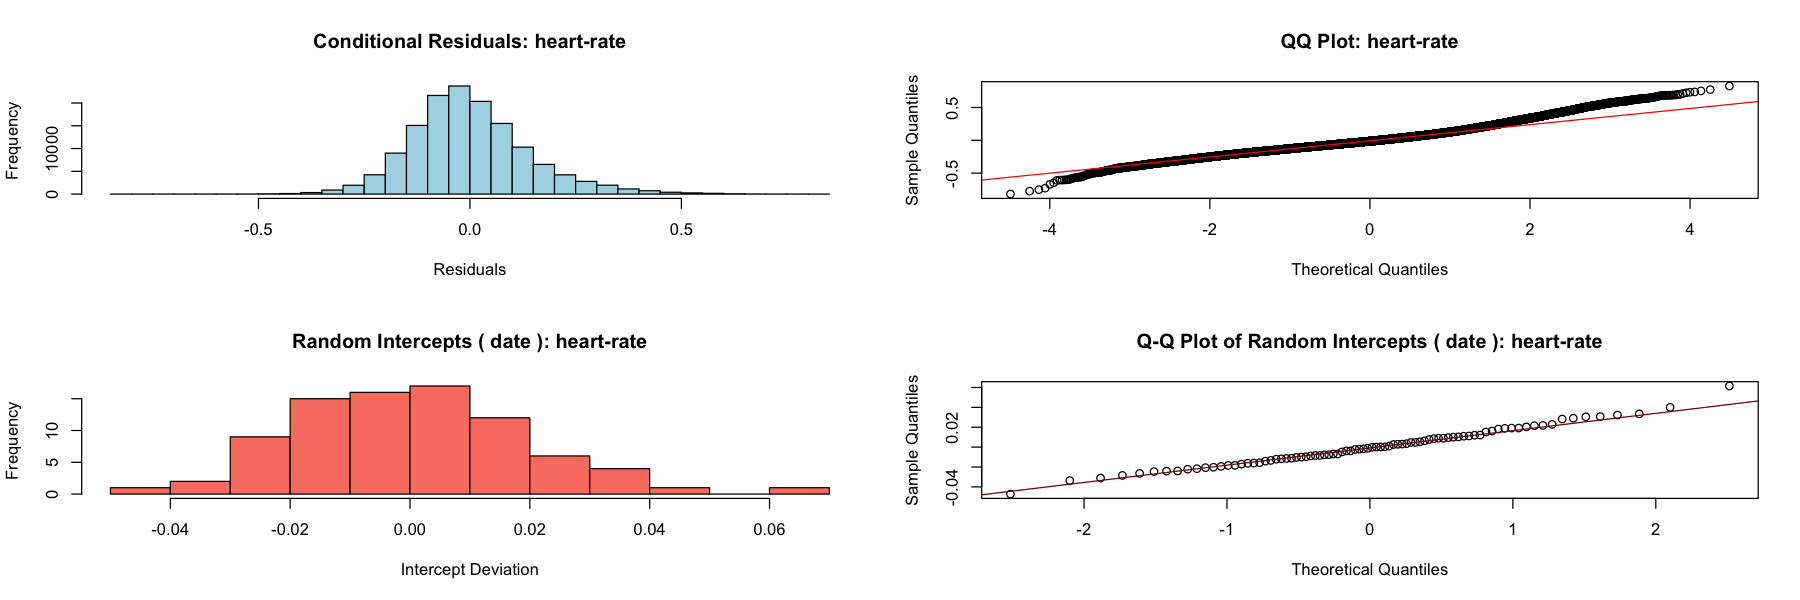

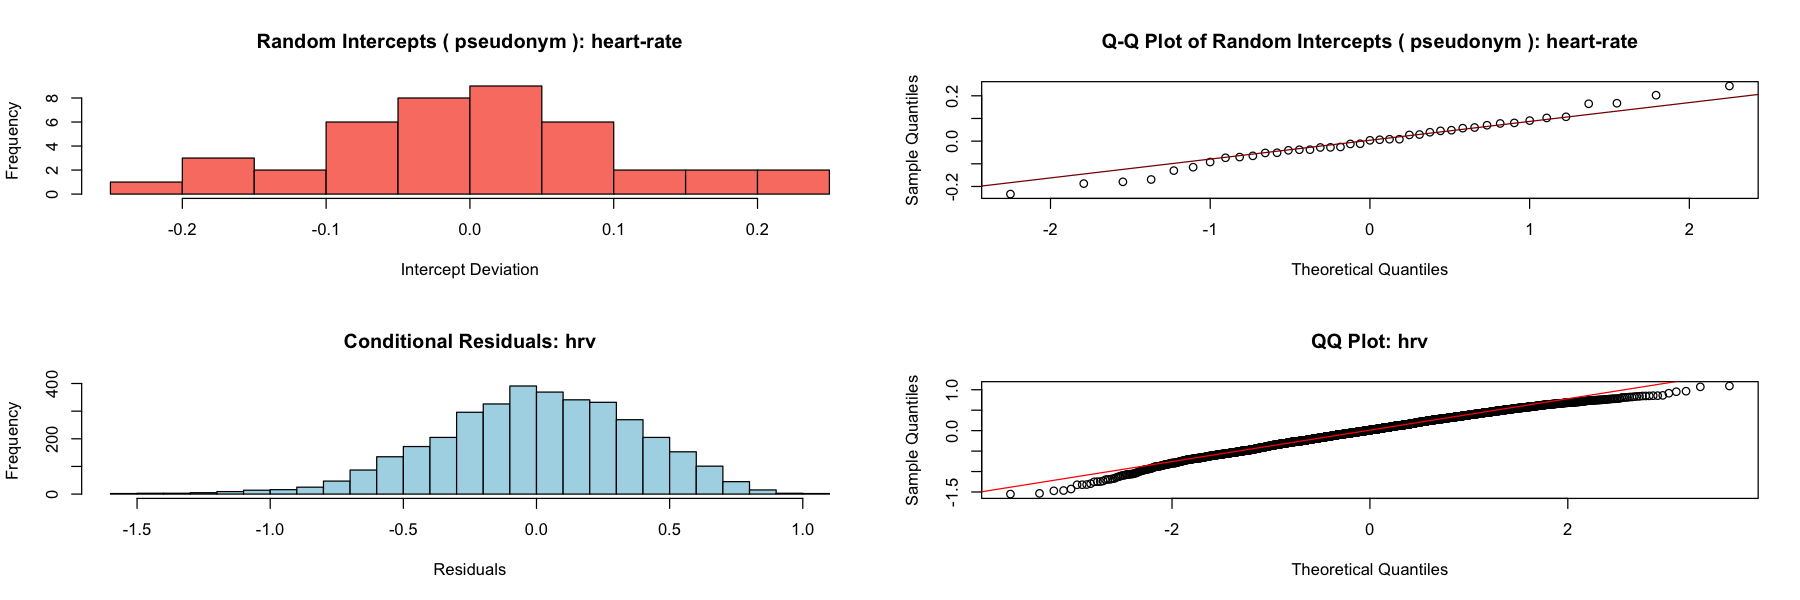

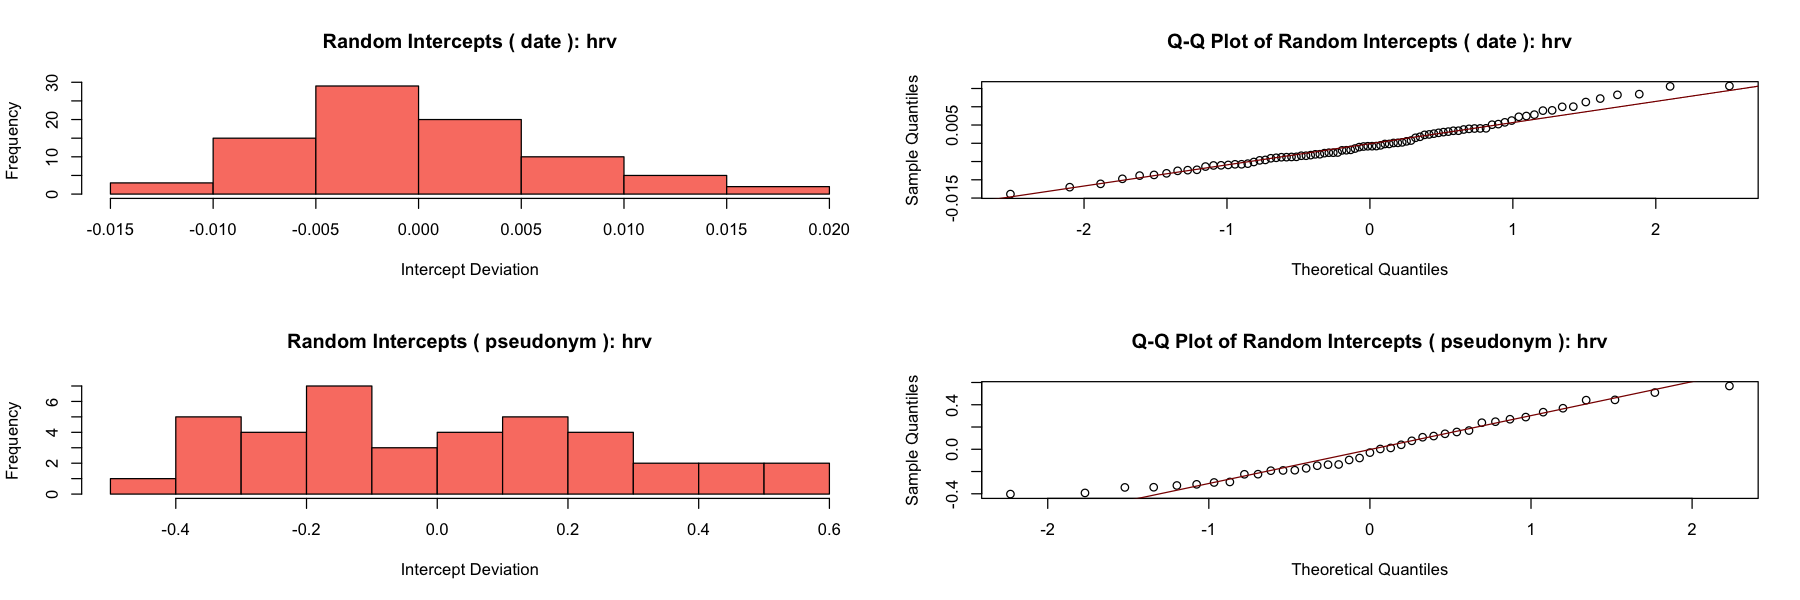

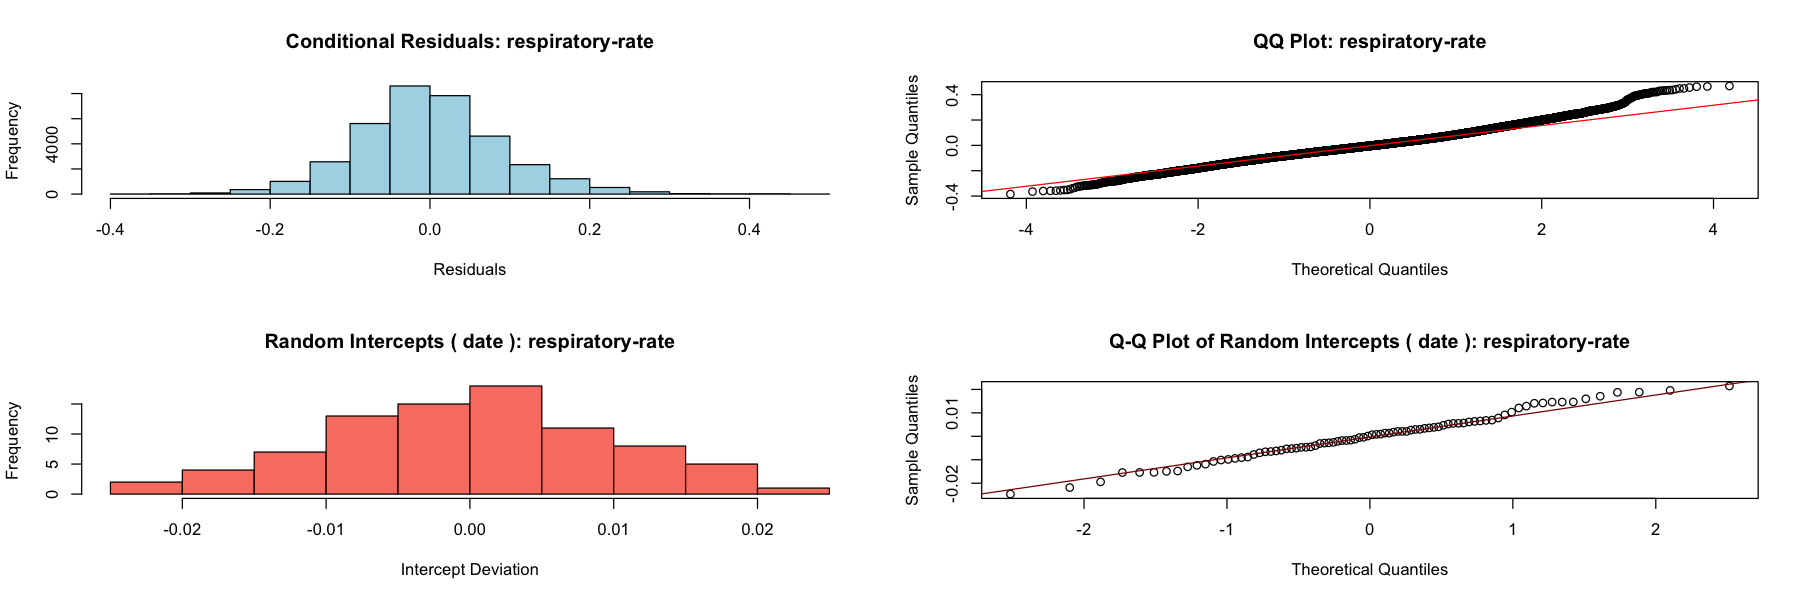

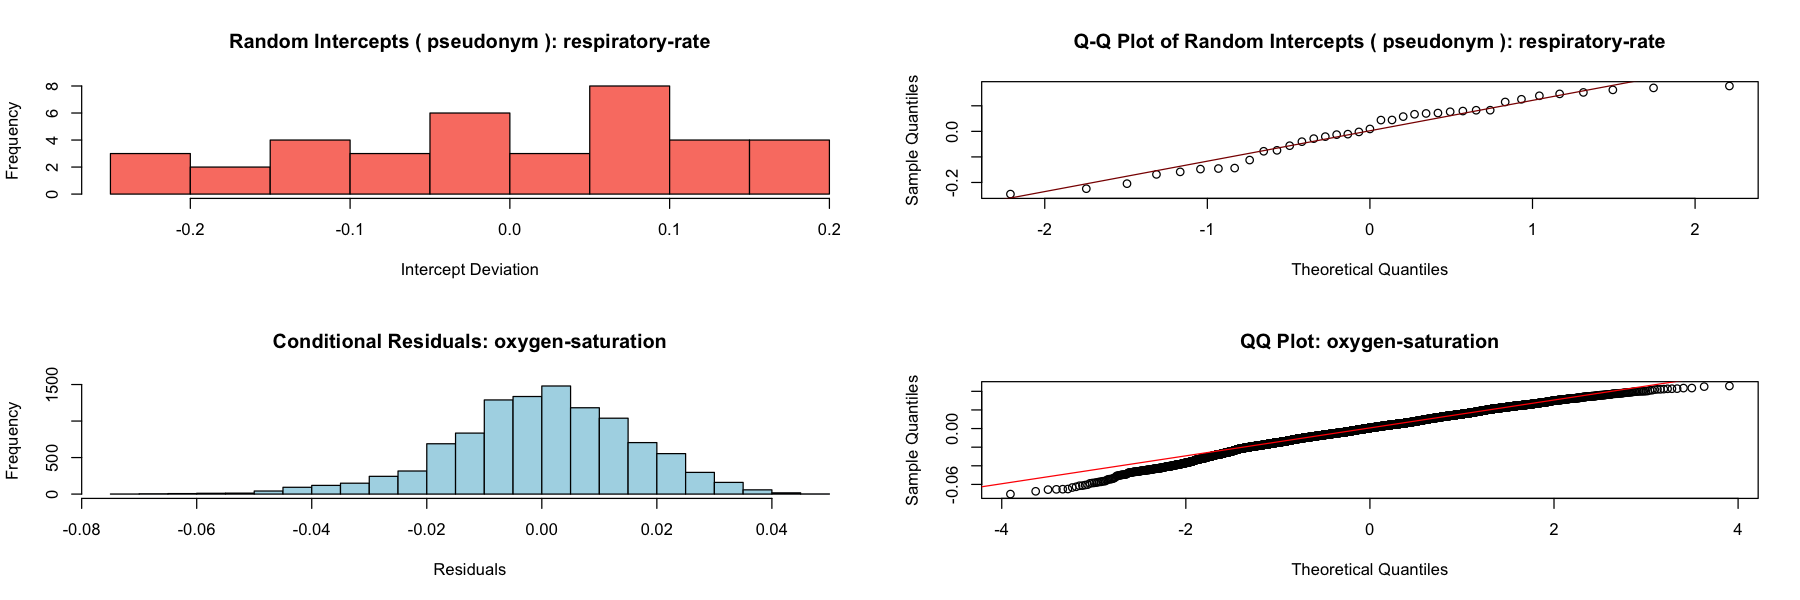

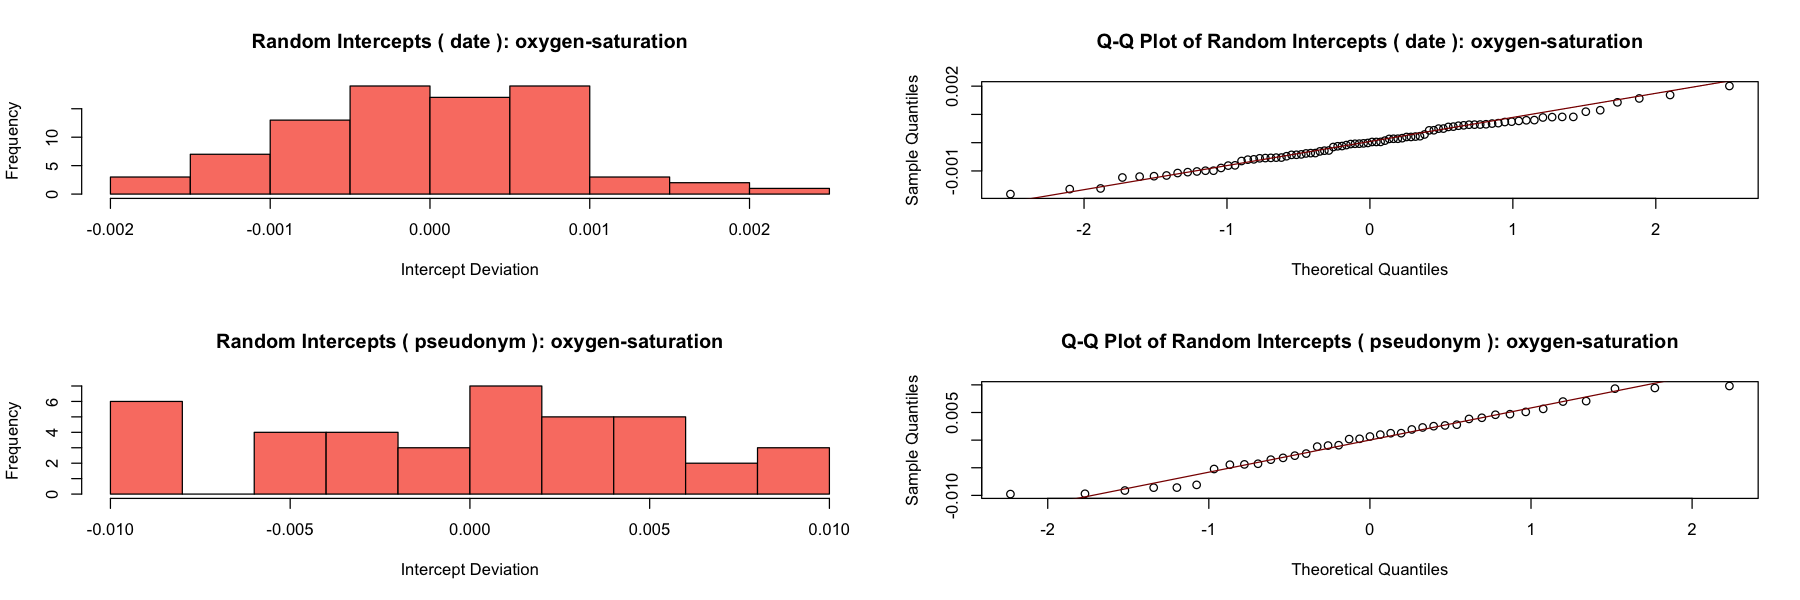

In [22]:
plot_lme_diagnostics(health_metric_pm25_lme_summaries)

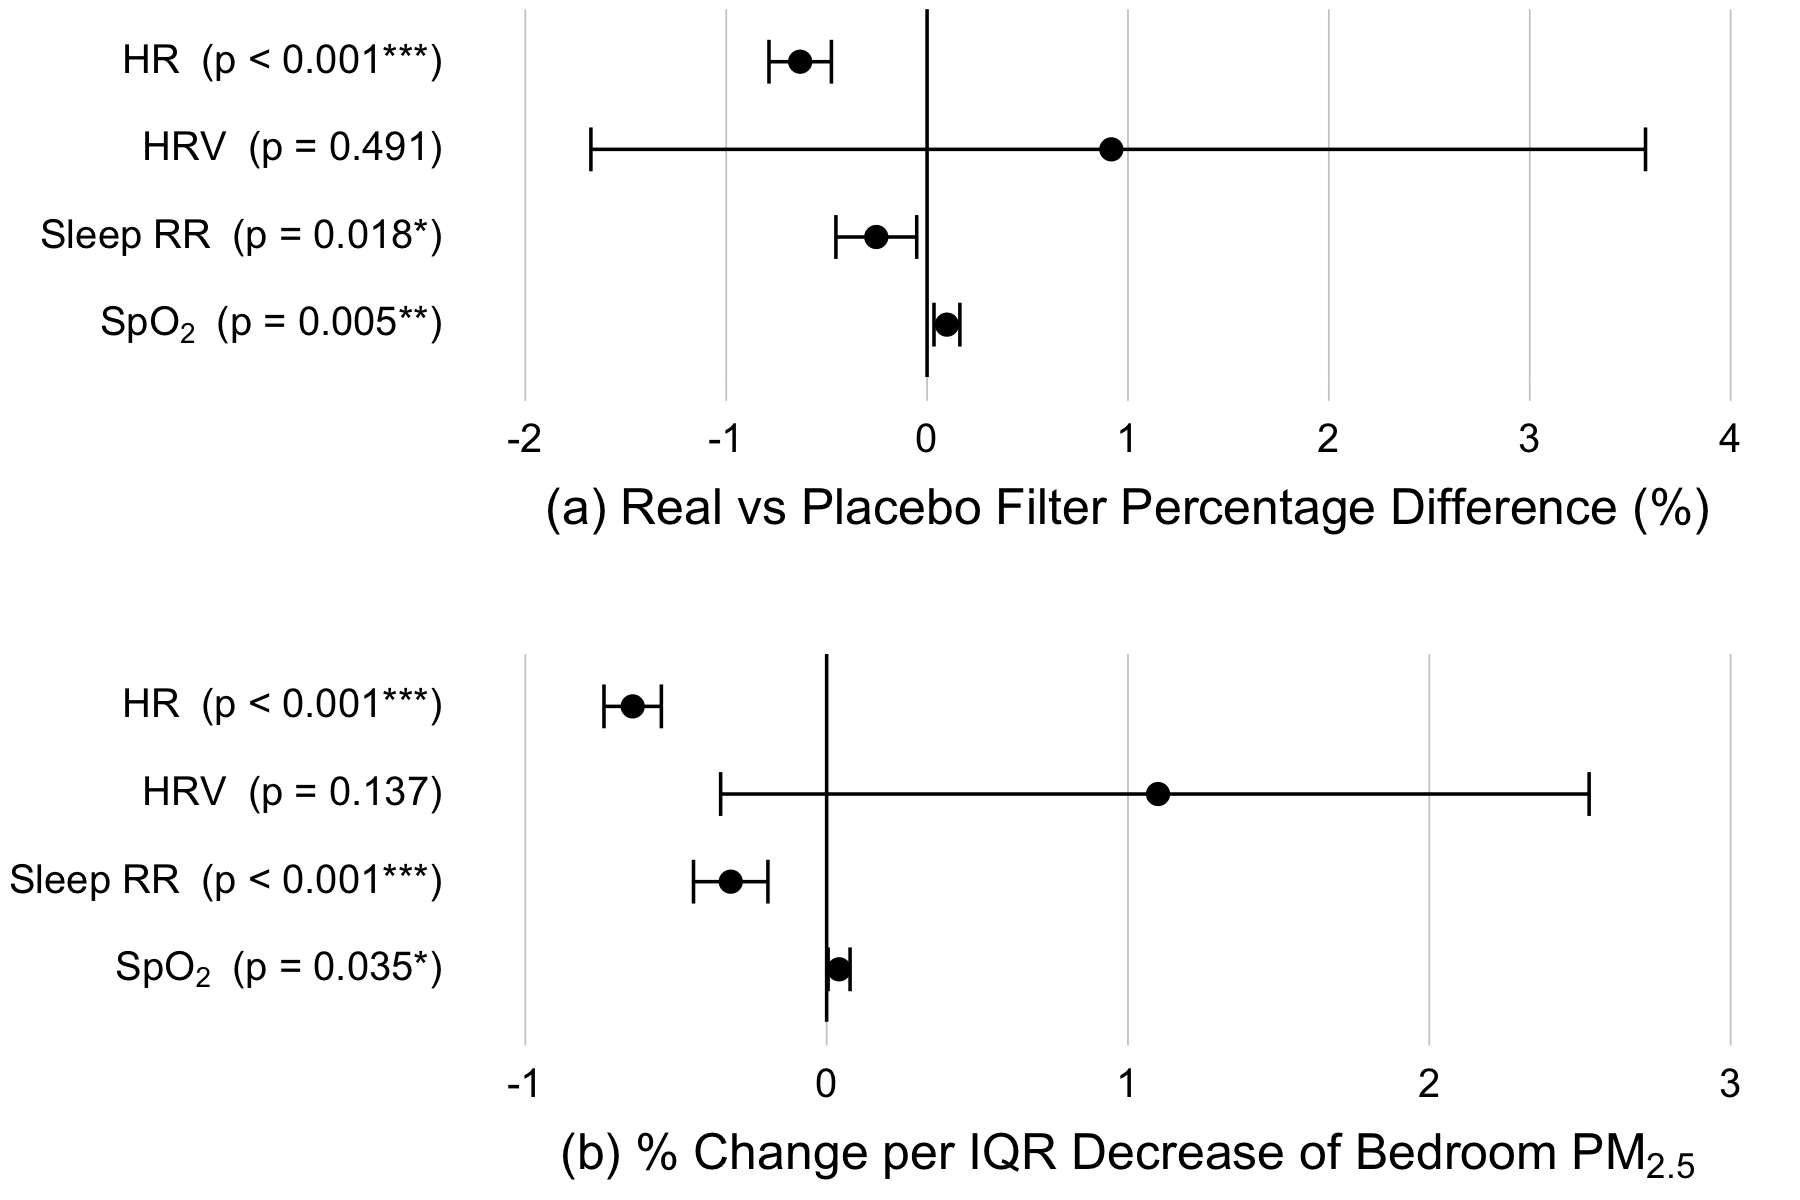

In [23]:
options(repr.plot.width = 15, repr.plot.height = 10)

combined_plot <- (
  p1 +
    theme(plot.margin = margin(0, 0, 36, 0))
) /
(
  p2 +
    theme(plot.margin = margin(36, 0, 0, 0))
)

combined_plot

dir.create("../visualization", showWarnings = FALSE)
ggsave(filename = file.path("../visualization", "percentage_change_health_metrics.pdf"), 
        plot = combined_plot, width = 15, height = 10, dpi = 300)

### 5.2.3. Exploratory and Sensitivity Analysis

#### 5.2.3.1. PM2.5 (all locations) <-> Health metric

In [24]:
pm25_lme_models_all_locations <- fit_lme_models(
    main_fixed_effect = "pm25",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)
pm25_lme_summaries_all_locations <- imap(pm25_lme_models_all_locations, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
pm25_lme_summaries_all_locations <- adjust_pvalues_bh(lme_summaries = pm25_lme_summaries_all_locations, main_fixed_effect = "pm25")

[1] "Fitting model for metric: heart-rate"
[1] "Fitting model for metric: resting-heart-rate"


boundary (singular) fit: see help('isSingular')



[1] "Fitting model for metric: hrv"
[1] "Fitting model for metric: respiratory-rate"
[1] "Fitting model for metric: oxygen-saturation"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 223822' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 223822)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 223822' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 223822)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for heart-rate = 73.84"
[1] "Adjusted overall mean for resting-heart-rate = 63.59"


...

[1] "Adjusted overall mean for hrv = 51.76"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 36401' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 36401)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 36401' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 36401)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for respiratory-rate = 14.85"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 13029' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 13029)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 13029' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 13029)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for oxygen-saturation = 97.22"


In [25]:
pm25_all_locations_report_df <- make_reporting_pm25_df(
  lme_summaries = pm25_lme_summaries_all_locations,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = HEALTH_METRIC_NAMES
)

pm25_all_locations_report_df

latex_tbl <- kable(
  pm25_all_locations_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccccc",
  col.names = c(
  "Metric", "N", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_pm25",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<int>,<dbl>,<chr>,<chr>
HR,223822,9.0,"$-0.89\%$ $[-1.02, -0.77]$",\textbf{<0.001$^{***}$}
HRV,5533,8.8,"$+1.43\%$ $[-0.22, +3.05]$",0.110
RHR,885,7.4,"$-1.17\%$ $[-2.00, -0.36]$",\textbf{0.008$^{**}$}
Sleep RR,36401,5.5,"$-0.39\%$ $[-0.52, -0.27]$",\textbf{<0.001$^{***}$}
SpO2,13029,7.1,"$+0.02\%$ $[-0.02, +0.07]$",0.274


\begin{table}[!h]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & N & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
HR & 223,822 & 9.0 & $-0.89\%$ $[-1.02, -0.77]$ & \textbf{<0.001$^{***}$}\\
HRV & 5,533 & 8.8 & $+1.43\%$ $[-0.22, +3.05]$ & 0.110\\
RHR & 885 & 7.4 & $-1.17\%$ $[-2.00, -0.36]$ & \textbf{0.008$^{**}$}\\
Sleep RR & 36,401 & 5.5 & $-0.39\%$ $[-0.52, -0.27]$ & \textbf{<0.001$^{***}$}\\
SpO2 & 13,029 & 7.1 & $+0.02\%$ $[-0.02, +0.07]$ & 0.274\\
\bottomrule
\end{tabular}
\end{table}

#### 5.2.3.2. Treatment <-> Health metric (no IQR outlier removal, no low-observation participant exclusion)

In [26]:
treatment_lme_models_sensitivity_no_removal <- fit_lme_models(
    main_fixed_effect = "treatment",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS
)

treatment_lme_summaries_sensitivity_no_removal <- imap(treatment_lme_models_sensitivity_no_removal, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "treatment"
        )
    )
treatment_lme_summaries_sensitivity_no_removal <- adjust_pvalues_bh(lme_summaries = treatment_lme_summaries_sensitivity_no_removal, main_fixed_effect = "treatmenttreatment2")

[1] "Fitting model for metric: heart-rate"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: hrv"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: respiratory-rate"


...

[1] "Adjusted overall mean for hrv = 55.1"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 36063' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 36063)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 36063' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 36063)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 36063' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 36063)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for respiratory-rate = 14.69"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10655' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10655)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10655' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10655)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10655' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10655)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for oxygen-saturation = 97.18"


In [27]:
treatment_sensitivity_no_removal_report_df <- make_reporting_treatment_df(
  lme_summaries = treatment_lme_summaries_sensitivity_no_removal,
  trt1 = "treatment1",
  trt2 = "treatment2",
  trt2_term = "treatmenttreatment2",
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)

treatment_sensitivity_no_removal_report_df

latex_tbl <- kable(
  treatment_sensitivity_no_removal_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccccc",
  col.names = c(
  "Metric",  "N", TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],  "Percentage Changes (Real vs. Placebo)", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_treatment",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,emmean1_pm_se,emmean2_pm_se,pct_change_iqr,p_value
<chr>,<int>,<chr>,<chr>,<chr>,<chr>
HR (beats/min),141510,$66.65~\pm~1.19$,$66.23~\pm~1.18$,"$-0.63\%$ $[-0.79, -0.48]$",\textbf{<0.001$^{***}$}
HRV (ms),3630,$54.89~\pm~2.74$,$55.31~\pm~2.76$,"$+0.77\%$ $[-1.80, +3.41]$",0.561
Sleep RR (breaths/min),36063,$14.71~\pm~0.32$,$14.68~\pm~0.32$,"$-0.19\%$ $[-0.39, +0.01]$",0.081
SpO$_2$ (\%),10655,$97.14~\pm~0.11$,$97.23~\pm~0.11$,"$+0.10\%$ $[+0.03, +0.16]$",\textbf{0.006$^{**}$}


\begin{table}[!h]
\centering
\begin{tabular}{lccccc}
\toprule
Metric & N & Placebo Filter & Real Filter & Percentage Changes (Real vs. Placebo) & P-Value\tnote{a}\\
\midrule
HR (beats/min) & 141,510 & $66.65~\pm~1.19$ & $66.23~\pm~1.18$ & $-0.63\%$ $[-0.79, -0.48]$ & \textbf{<0.001$^{***}$}\\
HRV (ms) & 3,630 & $54.89~\pm~2.74$ & $55.31~\pm~2.76$ & $+0.77\%$ $[-1.80, +3.41]$ & 0.561\\
Sleep RR (breaths/min) & 36,063 & $14.71~\pm~0.32$ & $14.68~\pm~0.32$ & $-0.19\%$ $[-0.39, +0.01]$ & 0.081\\
SpO$_2$ (\%) & 10,655 & $97.14~\pm~0.11$ & $97.23~\pm~0.11$ & $+0.10\%$ $[+0.03, +0.16]$ & \textbf{0.006$^{**}$}\\
\bottomrule
\end{tabular}
\end{table}

#### 5.2.3.3. PM2.5 <-> Health metric (no IQR outlier removal, no low-observation participant exclusion)

In [28]:
pm25_lme_models_sensitivity_no_removal <- fit_lme_models(
    main_fixed_effect = "pm25",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS
)
pm25_lme_summaries_sensitivity_no_removal <- imap(pm25_lme_models_sensitivity_no_removal, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
pm25_lme_summaries_sensitivity_no_removal <- adjust_pvalues_bh(lme_summaries = pm25_lme_summaries_sensitivity_no_removal, main_fixed_effect = "pm25")

[1] "Fitting model for metric: heart-rate"
[1] "Fitting model for metric: hrv"
[1] "Fitting model for metric: respiratory-rate"
[1] "Fitting model for metric: oxygen-saturation"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 141510' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 141510' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for heart-rate = 66.42"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3630' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3630)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3630' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3630)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for hrv = 55.12"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 36063' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 36063)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 36063' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 36063)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for respiratory-rate = 14.69"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10655' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10655)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10655' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10655)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for oxygen-saturation = 97.18"


In [29]:
pm25_sensitivity_no_removal_report_df <- make_reporting_pm25_df(
  lme_summaries = pm25_lme_summaries_sensitivity_no_removal,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = HEALTH_METRIC_NAMES
)

pm25_sensitivity_no_removal_report_df

latex_tbl <- kable(
  pm25_sensitivity_no_removal_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccccc",
  col.names = c(
  "Metric", "N", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_pm25",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<int>,<dbl>,<chr>,<chr>
HR,141510,5.4,"$-0.64\%$ $[-0.74, -0.55]$",\textbf{<0.001$^{***}$}
HRV,3630,5.5,"$+1.03\%$ $[-0.40, +2.45]$",0.157
Sleep RR,36063,5.3,"$-0.28\%$ $[-0.40, -0.15]$",\textbf{<0.001$^{***}$}
SpO2,10655,5.4,"$+0.04\%$ $[+0.00, +0.08]$",\textbf{0.042$^*$}


\begin{table}[!h]
\centering
\begin{tabular}{lcccc}
\toprule
Metric & N & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
HR & 141,510 & 5.4 & $-0.64\%$ $[-0.74, -0.55]$ & \textbf{<0.001$^{***}$}\\
HRV & 3,630 & 5.5 & $+1.03\%$ $[-0.40, +2.45]$ & 0.157\\
Sleep RR & 36,063 & 5.3 & $-0.28\%$ $[-0.40, -0.15]$ & \textbf{<0.001$^{***}$}\\
SpO2 & 10,655 & 5.4 & $+0.04\%$ $[+0.00, +0.08]$ & \textbf{0.042$^*$}\\
\bottomrule
\end{tabular}
\end{table}

# 5.3. LME for sleep stages durations

### 5.3.1. Treatment <-> Sleep stages durations

In [30]:
head(SLEEP_STAGE_WITH_EXPOSURE_DFS$awake)

pseudonym,period_id,sample_type_id,date,value,pm25,co2,temperature,humidity,heart_rate_motion_context,dow,treatment,treatment_order,first_or_second_half,bmi,biological_sex,age_group
<chr>,<dbl>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
apple3,1,awake,2025-02-19,0.06666667,16.240112,637.7437,23.37812,59.53132,0.00000000,Wednesday,treatment1,12,first_half,18.3,Female,31-35
apple3,1,awake,2025-02-22,0.02500000,18.521930,612.5570,23.75965,61.29783,-0.27777778,Saturday,treatment1,12,first_half,18.3,Female,31-35
apple3,1,awake,2025-02-23,0.10833333,12.632479,528.6902,23.42308,53.46687,0.00000000,Sunday,treatment1,12,first_half,18.3,Female,31-35
apple3,1,awake,2025-02-24,0.07500000,18.567196,501.2410,24.46823,61.45509,-0.09259259,Monday,treatment1,12,first_half,18.3,Female,31-35
apple3,1,awake,2025-02-26,0.04166667,4.840645,500.7476,22.83560,49.11571,-0.56478405,Wednesday,treatment1,12,first_half,18.3,Female,31-35
apple3,1,awake,2025-02-28,0.15833333,7.238293,530.3578,22.60270,49.55208,-0.23809524,Friday,treatment1,12,first_half,18.3,Female,31-35


In [31]:
sleep_stage_treatment_lme_models <- fit_lme_models(
    main_fixed_effect = "treatment",
    optional_filter_by_location_type = "home",
    metric_dfs = SLEEP_STAGE_WITH_EXPOSURE_DFS
)

sleep_stage_treatment_lme_summaries <- imap(
  sleep_stage_treatment_lme_models,
  ~ extract_model_info(
      model = .x$model,
      main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
      df_used = .x$df_used,
      metric_name = .y,
      main_fixed_effect = "treatment"
    )
)

sleep_stage_treatment_lme_summaries <- adjust_pvalues_bh(lme_summaries = sleep_stage_treatment_lme_summaries, main_fixed_effect = "treatmenttreatment2")

[1] "Fitting model for metric: awake"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: asleep_core"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: asleep_deep"


...

[1] "Fitting model for metric: asleep_rem"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: alseep_all"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Adjusted overall mean for awake = 0.16"
[1] "Adjusted overall mean for asleep_core = 3.94"
[1] "Adjusted overall mean for asleep_deep = 0.86"
[1] "Adjusted overall mean for asleep_rem = 1.36"
[1] "Adjusted overall mean for alseep_all = 6.65"


In [32]:
view_lme_summary_details(lme_summaries = sleep_stage_treatment_lme_summaries)

log(value) ~ treatment + treatment_order + first_or_second_half + 
    bmi + biological_sex + ns(temperature, df = 3) + ns(humidity, 
    df = 3) + ns(co2, df = 3) + dow + heart_rate_motion_context + 
    (1 | pseudonym + date)
<environment: 0x13b24f3d8>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
awake,2042.966,0.9140996,730


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),-2.54377810,-4.093413545,-0.994142664,0.79064485,-3.2173461,191.55237,1.519229e-03,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,0.05582603,-0.081714842,0.193366906,0.07017520,0.7955236,665.92732,4.265924e-01,5.741371,-7.8465296,21.3327889,NA,NA,NA,0.4265924
fixed,treatment_order,-0.04306566,-0.089804619,0.003673307,0.02384685,-1.8059266,32.38527,8.023229e-02,-4.215150,-8.5890233,0.3680061,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,-0.07989315,-0.229462628,0.069676328,0.07631236,-1.0469228,67.77887,2.988543e-01,-7.678501,-20.5039323,7.2161096,NA,NA,NA,NA
fixed,bmi,0.20815647,-0.008952437,0.425265381,0.11077189,1.8791453,35.81120,6.838234e-02,23.140584,-0.8912483,52.9996398,NA,NA,NA,NA
fixed,biological_sexMale,-0.19626282,-0.603857772,0.211332127,0.20796043,-0.9437508,34.02052,3.519515e-01,-17.820378,-45.3301475,23.5322571,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",-0.53590464,-1.433841752,0.362032471,0.45813960,-1.1697409,502.65377,2.426596e-01,-41.486029,-76.1608680,43.6245578,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.91614255,-1.047225101,2.879510201,1.00173660,0.9145543,294.77589,3.611731e-01,149.962957,-64.9089861,1680.5549906,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",1.67913248,-0.232155290,3.590420243,0.97516474,1.7218962,706.29788,8.552614e-02,436.090324,-20.7177003,3524.9306230,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.01770654,0.1330659,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.28649293,0.5352503,NA,NA
ran_pars,Residual,sd__Observation,0.83557813,0.9140996,NA,NA


,treatment,response,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,0.1594655,0.01873296,56.21738,0.1260300,0.2017714
2,treatment2,0.1686210,0.01973468,56.57632,0.1333871,0.2131618


...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
alseep_all,295.4956,0.2665481,796


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),1.722685242,1.3180139644,2.127356520,0.206468732,8.3435648,275.15404,3.525123e-15,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,-0.032574359,-0.0708017536,0.005653035,0.019504131,-1.6701262,716.89791,9.533092e-02,-3.2049529,-6.83534306,0.5669043,NA,NA,NA,0.205067
fixed,treatment_order,-0.001915797,-0.0112556830,0.007424089,0.004765335,-0.4020277,29.49143,6.905625e-01,-0.1913963,-1.11925748,0.7451716,NA,NA,NA,NA
fixed,first_or_second_halfsecond_half,-0.020967631,-0.0627236077,0.020788347,0.021304461,-0.9841897,56.38542,3.292267e-01,-2.0749338,-6.07969737,2.1005929,NA,NA,NA,NA
fixed,bmi,-0.022367403,-0.0673629737,0.022628168,0.022957346,-0.9743027,32.52789,3.370966e-01,-2.2119107,-6.51441884,2.2886127,NA,NA,NA,NA
fixed,biological_sexMale,-0.022281056,-0.1060332306,0.061471119,0.042731487,-0.5214201,31.59405,6.057103e-01,-2.2034666,-10.06052398,6.3399785,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.038701552,-0.1601081918,0.237511296,0.101435407,0.3815389,297.60369,7.030757e-01,3.9460212,-14.79484010,26.8089321,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",-0.815950860,-1.3098849317,-0.322016789,0.252011810,-3.2377485,269.54442,1.355556e-03,-55.7781361,-73.01488941,-27.5313977,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-1.303337262,-1.7588131630,-0.847861361,0.232389934,-5.6084067,636.60223,3.046254e-08,-72.8376201,-82.77508257,-57.1670004,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.001391102,0.03729748,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.010652074,0.10320888,NA,NA
ran_pars,Residual,sd__Observation,0.071047910,0.26654814,NA,NA


,treatment,response,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,6.758301,0.1774536,71.67920,6.413626,7.121498
2,treatment2,6.541700,0.1737354,75.28768,6.204618,6.897095


[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"


In [33]:
sleep_stage_treatment_report_df <- make_reporting_treatment_df(
  lme_summaries = sleep_stage_treatment_lme_summaries,
  trt1 = "treatment1",
  trt2 = "treatment2",
  trt2_term = "treatmenttreatment2",
  metric_labels = SLEEP_STAGE_LABELS_LATEX
)

sleep_stage_treatment_report_df

latex_tbl <- kable(
  sleep_stage_treatment_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lccccc",
  col.names = c(
  "Sleep Stage", "N",  TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "Percentage Changes (Real vs. Placebo)", "P-Value\\tnote{a}"),
  label = "sleep_stage_vs_treatment",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,emmean1_pm_se,emmean2_pm_se,pct_change_iqr,p_value
<chr>,<int>,<chr>,<chr>,<chr>,<chr>
Awake (h),730,$0.16~\pm~0.02$,$0.17~\pm~0.02$,"$+5.74\%$ $[-7.85, +21.33]$",0.427
Core (h),775,$4.02~\pm~0.14$,$3.86~\pm~0.13$,"$-4.01\%$ $[-7.74, -0.13]$",0.205
Deep (h),774,$0.84~\pm~0.04$,$0.88~\pm~0.04$,"$+4.27\%$ $[-1.12, +9.95]$",0.205
REM (h),739,$1.37~\pm~0.07$,$1.34~\pm~0.06$,"$-2.26\%$ $[-7.45, +3.23]$",0.427
Total (h),796,$6.76~\pm~0.18$,$6.54~\pm~0.17$,"$-3.20\%$ $[-6.84, +0.57]$",0.205


\begin{table}[!h]
\centering
\begin{tabular}{lccccc}
\toprule
Sleep Stage & N & Placebo Filter & Real Filter & Percentage Changes (Real vs. Placebo) & P-Value\tnote{a}\\
\midrule
Awake (h) & 730 & $0.16~\pm~0.02$ & $0.17~\pm~0.02$ & $+5.74\%$ $[-7.85, +21.33]$ & 0.427\\
Core (h) & 775 & $4.02~\pm~0.14$ & $3.86~\pm~0.13$ & $-4.01\%$ $[-7.74, -0.13]$ & 0.205\\
Deep (h) & 774 & $0.84~\pm~0.04$ & $0.88~\pm~0.04$ & $+4.27\%$ $[-1.12, +9.95]$ & 0.205\\
REM (h) & 739 & $1.37~\pm~0.07$ & $1.34~\pm~0.06$ & $-2.26\%$ $[-7.45, +3.23]$ & 0.427\\
Total (h) & 796 & $6.76~\pm~0.18$ & $6.54~\pm~0.17$ & $-3.20\%$ $[-6.84, +0.57]$ & 0.205\\
\bottomrule
\end{tabular}
\end{table}

### 5.3.2. PM2.5 exposure <-> Sleep stages durations

In [34]:
sleep_stage_pm25_lme_models <- fit_lme_models(
    main_fixed_effect = "pm25",
    metric_dfs = SLEEP_STAGE_WITH_EXPOSURE_DFS
)
sleep_stage_pm25_lme_summaries <- imap(sleep_stage_pm25_lme_models, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
sleep_stage_pm25_lme_summaries <- adjust_pvalues_bh(lme_summaries = sleep_stage_pm25_lme_summaries, main_fixed_effect = "pm25")

[1] "Fitting model for metric: awake"
[1] "Fitting model for metric: asleep_core"
[1] "Fitting model for metric: asleep_deep"


boundary (singular) fit: see help('isSingular')



[1] "Fitting model for metric: asleep_rem"
[1] "Fitting model for metric: alseep_all"
[1] "Adjusted overall mean for awake = 0.16"
[1] "Adjusted overall mean for asleep_core = 3.94"
[1] "Adjusted overall mean for asleep_deep = 0.86"
[1] "Adjusted overall mean for asleep_rem = 1.36"
[1] "Adjusted overall mean for alseep_all = 6.66"


In [35]:
sleep_stage_pm25_report_df <- make_reporting_pm25_df(
  lme_summaries = sleep_stage_pm25_lme_summaries,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = SLEEP_STAGE_LABELS_LATEX
)

sleep_stage_pm25_report_df

latex_tbl <- kable(
  sleep_stage_pm25_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "lcccc",
  col.names = c(
  "Sleep Stage", "N", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "sleep_stage_vs_pm25",
  format.args = list(big.mark = ",", scientific = FALSE)
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,nobs,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<int>,<dbl>,<chr>,<chr>
Awake (h),730,5.9,"$+1.91\%$ $[-6.31, +9.50]$",0.798
Core (h),775,5.6,"$-0.71\%$ $[-3.22, +1.75]$",0.798
Deep (h),774,6.1,"$+2.85\%$ $[-0.48, +6.07]$",0.463
REM (h),739,5.6,"$-0.15\%$ $[-3.44, +3.02]$",0.926
Total (h),796,5.6,"$-1.04\%$ $[-3.36, +1.24]$",0.798


\begin{table}[!h]
\centering
\begin{tabular}{lcccc}
\toprule
Sleep Stage & N & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
Awake (h) & 730 & 5.9 & $+1.91\%$ $[-6.31, +9.50]$ & 0.798\\
Core (h) & 775 & 5.6 & $-0.71\%$ $[-3.22, +1.75]$ & 0.798\\
Deep (h) & 774 & 6.1 & $+2.85\%$ $[-0.48, +6.07]$ & 0.463\\
REM (h) & 739 & 5.6 & $-0.15\%$ $[-3.44, +3.02]$ & 0.926\\
Total (h) & 796 & 5.6 & $-1.04\%$ $[-3.36, +1.24]$ & 0.798\\
\bottomrule
\end{tabular}
\end{table}